# Orbit Wars — Full Pipeline
## Env → BC → PPO Self-Play → PFSP → Submission
**Target: 1200+ ELO | GPU: T4 x2**

In [16]:
# ============================================================
# CELL 1: INSTALL & IMPORTS
# ============================================================
!pip install -q numpy scipy tqdm matplotlib

import os, sys, copy, time, random, math, json, pickle
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field
from collections import deque, defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Device setup (T4 x2)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'GPUs available: {torch.cuda.device_count()}')

# ── Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: cuda
GPUs available: 2


In [90]:
# ============================================================
# CELL 2: GLOBAL CONFIG
# ============================================================

class Config:
    MAP_W          = 100   
    MAP_H          = 100     
    N_PLANETS      = 12
    MAX_FLEETS     = 30     
    MAX_TURNS      = 400    

    PLANET_FEAT    = 6         
    FLEET_FEAT     = 5
    D_MODEL        = 128
    N_HEADS        = 8
    N_LAYERS       = 4

    # ── Candidates
    MAX_CANDIDATES = 50
    SIM_TURNS      = 8
    FUTURE_DIM     = 10
    CAND_RAW_DIM   = 32

    # ── Training
    LR_BC          = 3e-4
    LR_PPO         = 1e-4
    BC_EPOCHS      = 10
    BC_BATCH       = 256
    BC_SAMPLES     = 150_000

    PPO_EPOCHS     = 4
    PPO_BATCH      = 512
    PPO_CLIP       = 0.2
    ENTROPY_COEF   = 0.01
    VALUE_COEF     = 0.5
    GAE_LAMBDA     = 0.95
    GAMMA          = 0.99
    MAX_GRAD_NORM  = 0.5

    SELFPLAY_ITERS = 150
    GAMES_PER_ITER = 8
    ROLLOUT_STEPS  = 256

    # ── PFSP
    POOL_SIZE      = 20
    PFSP_ALPHA     = 1.0       # weighting sharpness

    # ── Inference
    INFERENCE_MS   = 45        # target < 50ms

CFG = Config()
print('Config loaded ✓')

Config loaded ✓


In [18]:
# XÓA toàn bộ class OrbitWarsEnv, Planet, Fleet, GameState tự tạo
# THAY bằng wrapper dùng kaggle_environments:

from kaggle_environments import make
from kaggle_environments.envs.orbit_wars.orbit_wars import Planet as KPlanet
import math

def make_env(seed=42):
    return make("orbit_wars", configuration={"seed": seed}, debug=False)

# Adapter: convert Kaggle obs → format pipeline dùng
def kaggle_obs_to_pipeline(obs_raw) -> dict:
    """
    Kaggle obs fields:
      obs.player  — int (0-3)
      obs.planets — list of [id, owner, x, y, radius, ships, production]
                    owner = -1 (neutral), 0/1/2/3 (player index)
      obs.fleets  — list of [id, owner, x, y, angle, from_planet_id, ships]
    
    Pipeline dùng:
      my_player   — 1 hoặc 2 (mapped từ 0/1)
      planets     — list dict với owner: 0=neutral, 1=mine, 2=enemy
      fleets      — list dict
    """
    # Handle both dict and namespace
    if hasattr(obs_raw, '__dict__'):
        player   = obs_raw.player
        planets  = obs_raw.planets
        fleets   = getattr(obs_raw, 'fleets', [])
    else:
        player   = obs_raw.get('player', 0)
        planets  = obs_raw.get('planets', [])
        fleets   = obs_raw.get('fleets', [])

    me  = int(player)   # 0-indexed từ Kaggle
    opp = 1 - me        # chỉ 1v1

    # Convert planets
    planet_list = []
    for p in planets:
        # p = [id, owner, x, y, radius, ships, production]
        pid, raw_owner, x, y, radius, ships, production = p
        if raw_owner == -1:
            owner_enc = 0   # neutral
        elif raw_owner == me:
            owner_enc = 1   # mine
        else:
            owner_enc = 2   # enemy
        planet_list.append({
            'id': int(pid),
            'owner': owner_enc,
            'x': float(x),
            'y': float(y),
            'radius': float(radius),
            'ships': float(ships),
            'production': float(production),
        })

    # Convert fleets
    fleet_list = []
    for f in fleets:
        # f = [id, owner, x, y, angle, from_planet_id, ships]
        fid, raw_owner, fx, fy, angle, from_pid, ships = f
        if raw_owner == me:
            owner_enc = 1
        else:
            owner_enc = 2
        fleet_list.append({
            'id': int(fid),
            'owner': owner_enc,
            'x': float(fx),
            'y': float(fy),
            'angle': float(angle),
            'from_planet_id': int(from_pid),
            'ships': float(ships),
        })

    return {
        'my_player': 1,   # pipeline luôn dùng 1=me, 2=enemy
        'planets': planet_list,
        'fleets': fleet_list,
        'turn': 0,
    }

# Test
env = make_env(seed=42)
env.reset()
raw_obs = env.state[0]['observation']
obs = kaggle_obs_to_pipeline(raw_obs)
print(f"Planets: {len(obs['planets'])}")
print(f"Sample planet: {obs['planets'][0]}")
print('Kaggle env adapter ✓')

Planets: 20
Sample planet: {'id': 0, 'owner': 1, 'x': 68.17313810856307, 'y': 94.88924011533776, 'radius': 2.09861228866811, 'ships': 10.0, 'production': 3.0}
Kaggle env adapter ✓


In [21]:
# ============================================================
# CELL 4: STATE PARSER (Module 1)
# ============================================================

# SỬA: planet có thêm trường radius, map 100x100
def parse_obs(obs: Dict, cfg: Config = CFG) -> Tuple[torch.Tensor, torch.Tensor]:
    planets = obs['planets']
    fleets  = obs['fleets']

    p_rows = []
    for p in planets:
        owner_enc = p['owner'] / 2.0
        row = [
            owner_enc,
            min(p['ships'] / 500.0, 1.0),        # ← /1000 → /500
            p.get('production', 1) / 10.0,        # ← /5 → /10
            p['x'] / 100.0,                        # ← MAP_W=100
            p['y'] / 100.0,                        # ← MAP_H=100
            p.get('radius', 5) / 20.0,            # ← THÊM radius feature
        ]
        p_rows.append(row)

    while len(p_rows) < cfg.N_PLANETS:
        p_rows.append([0.0] * cfg.PLANET_FEAT)
    p_rows = p_rows[:cfg.N_PLANETS]
    planet_tensor = torch.tensor(p_rows, dtype=torch.float32)  # [N_p, 6]

    # Fleet: dùng angle thay vì source_id/target_id/eta
    f_rows = []
    for f in fleets:
        owner_enc = f['owner'] / 2.0
        row = [
            owner_enc,
            min(f['ships'] / 500.0, 1.0),
            f['x'] / 100.0,
            f['y'] / 100.0,
            f.get('angle', 0) / (2 * math.pi),   # ← normalize angle
        ]
        f_rows.append(row)

    while len(f_rows) < cfg.MAX_FLEETS:
        f_rows.append([0.0] * cfg.FLEET_FEAT)
    f_rows = f_rows[:cfg.MAX_FLEETS]
    fleet_tensor = torch.tensor(f_rows, dtype=torch.float32)

    return planet_tensor, fleet_tensor


# Test
pt, ft = parse_obs(obs)
print(f'planet_tensor: {pt.shape}')   # [12, 5]
print(f'fleet_tensor:  {ft.shape}')   # [20, 5]
print('State Parser ✓')

planet_tensor: torch.Size([12, 6])
fleet_tensor:  torch.Size([30, 5])
State Parser ✓


In [25]:
# ============================================================
# CELL 5: OBJECT ENCODER + TRANSFORMER (Modules 2 & 3)
# ============================================================

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dims, out_dim, act=nn.GELU):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), act(), nn.LayerNorm(h)]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class ObjectEncoder(nn.Module):
    """
    Encodes planet + fleet tensors into d_model embeddings.
    Also injects owner embedding (mine/enemy/neutral).
    """
    def __init__(self, cfg: Config = CFG):
        super().__init__()
        d = cfg.D_MODEL
        # Owner embedding
        self.owner_emb = nn.Embedding(3, 16)  # 0=neutral,1=mine,2=enemy

        # Planet: 5 raw + 16 owner emb = 21 → 128
        self.planet_enc = MLP(cfg.PLANET_FEAT - 1 + 16, [64], d)
        # Fleet:  5 raw + 16 owner emb = 21 → 128
        self.fleet_enc  = MLP(cfg.FLEET_FEAT  - 1 + 16, [64], d)

        # CLS token parameter
        self.cls_token  = nn.Parameter(torch.randn(1, 1, d))

    def forward(self, planet_t: torch.Tensor, fleet_t: torch.Tensor):
        """
        planet_t: [B, N_p, 5]  or  [N_p, 5] (will unsqueeze)
        fleet_t:  [B, N_f, 5]  or  [N_f, 5]
        Returns tokens: [B, 1+N_p+N_f, d_model]
        """
        batched = planet_t.dim() == 3
        if not batched:
            planet_t = planet_t.unsqueeze(0)
            fleet_t  = fleet_t.unsqueeze(0)

        B, N_p, _ = planet_t.shape
        _, N_f, _ = fleet_t.shape

        # Extract owner index (0,1,2) from normalised owner (0, 0.5, 1)
        p_owner_idx = (planet_t[..., 0] * 2).long().clamp(0, 2)  # [B, N_p]
        f_owner_idx = (fleet_t[..., 0]  * 2).long().clamp(0, 2)  # [B, N_f]

        p_owner_e = self.owner_emb(p_owner_idx)   # [B, N_p, 16]
        f_owner_e = self.owner_emb(f_owner_idx)   # [B, N_f, 16]

        # Drop raw owner column, concat owner embedding
        p_feat = torch.cat([planet_t[..., 1:], p_owner_e], dim=-1)  # [B, N_p, 4+16]
        f_feat = torch.cat([fleet_t[..., 1:],  f_owner_e], dim=-1)  # [B, N_f, 4+16]

        p_emb = self.planet_enc(p_feat)   # [B, N_p, d]
        f_emb = self.fleet_enc(f_feat)    # [B, N_f, d]

        cls = self.cls_token.expand(B, -1, -1)   # [B, 1, d]
        tokens = torch.cat([cls, p_emb, f_emb], dim=1)  # [B, 1+N_p+N_f, d]

        return tokens


class StateEncoder(nn.Module):
    """
    ObjectEncoder + Transformer → state_embedding [B, d_model]
    """
    def __init__(self, cfg: Config = CFG):
        super().__init__()
        self.obj_enc = ObjectEncoder(cfg)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=cfg.D_MODEL,
            nhead=cfg.N_HEADS,
            dim_feedforward=cfg.D_MODEL * 4,
            dropout=0.1,
            batch_first=True,
            norm_first=False,   # Pre-LN for training stability
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=cfg.N_LAYERS)

    def forward(self, planet_t: torch.Tensor, fleet_t: torch.Tensor) -> torch.Tensor:
        tokens = self.obj_enc(planet_t, fleet_t)   # [B, T, d]
        out    = self.transformer(tokens)           # [B, T, d]
        state_emb = out[:, 0, :]                    # CLS token → [B, d]
        return state_emb


# Test
enc = StateEncoder(CFG).to(DEVICE)
pt_b = pt.unsqueeze(0).to(DEVICE)
ft_b = ft.unsqueeze(0).to(DEVICE)
emb = enc(pt_b, ft_b)
print(f'state_embedding: {emb.shape}')   # [1, 128]
print('StateEncoder ✓')

state_embedding: torch.Size([1, 128])
StateEncoder ✓


In [26]:
# ============================================================
# CELL 6: CANDIDATE GENERATOR
# ============================================================

@dataclass
class Candidate:
    source:      int
    angle:       float
    ships:       float
    action_type: str
    target_id:   int = -1

    def to_action(self) -> list:
        return [self.source, self.angle, self.ships]


def _dist2(a, b) -> float:
    return math.sqrt((a['x']-b['x'])**2 + (a['y']-b['y'])**2)

def _angle_to(src, tgt) -> float:
    return math.atan2(tgt['y'] - src['y'], tgt['x'] - src['x'])


def generate_candidates(obs: Dict, cfg: Config = CFG) -> List[Candidate]:
    planets = obs['planets']

    mine    = [p for p in planets if p['owner'] == 1]
    neutral = [p for p in planets if p['owner'] == 0]
    enemy   = [p for p in planets if p['owner'] == 2]

    if not mine:
        return []

    candidates = []

    # ==========================================================
    # EXPAND
    # ==========================================================
    def expand_candidates():
        cands = []
        for src in mine:
            if src['ships'] < 2:
                continue

            by_dist = sorted(neutral, key=lambda t: _dist2(src, t))[:5]
            by_prod = sorted(neutral, key=lambda t: -t.get('production', 1))[:5]

            targets = {t['id']: t for t in (by_dist + by_prod)}

            for tgt in targets.values():
                angle = _angle_to(src, tgt)

                for ratio in [0.3, 0.5, 0.7, 0.9]:
                    send = src['ships'] * ratio
                    if send > 1:
                        cands.append(Candidate(src['id'], angle, send, 'expand', tgt['id']))

                send = min(tgt['ships'] + 5, src['ships'] - 1)
                if send > 1:
                    cands.append(Candidate(src['id'], angle, send, 'expand', tgt['id']))
        return cands


    # ==========================================================
    # ATTACK
    # ==========================================================
    def attack_candidates():
        cands = []
        for src in mine:
            if src['ships'] < 2:
                continue

            by_ships = sorted(enemy, key=lambda t: t['ships'])[:5]
            by_prod  = sorted(enemy, key=lambda t: -t.get('production', 1))[:5]

            targets = {t['id']: t for t in (by_ships + by_prod)}

            for tgt in targets.values():
                angle = _angle_to(src, tgt)

                for ratio in [0.4, 0.6, 0.8, 1.0]:
                    send = src['ships'] * ratio
                    if send > 1:
                        cands.append(Candidate(src['id'], angle, send, 'attack', tgt['id']))

                send = min(tgt['ships'] * 1.5 + 10, src['ships'] - 1)
                if send > 1:
                    cands.append(Candidate(src['id'], angle, send, 'attack', tgt['id']))
        return cands


    # ==========================================================
    # DEFENSE
    # ==========================================================
    def defense_candidates():
        cands = []
        threatened = {}

        for f in obs.get('fleets', []):
            if f['owner'] != 2:
                continue

            for p in mine:
                ang_to_p = math.atan2(p['y'] - f['y'], p['x'] - f['x'])
                diff = abs(ang_to_p - f.get('angle', 0))
                diff = min(diff, 2 * math.pi - diff)

                if diff < 0.25:
                    threatened[p['id']] = threatened.get(p['id'], 0) + f['ships']

        for pid, incoming in sorted(threatened.items(), key=lambda x: -x[1])[:5]:
            tgt = next((p for p in mine if p['id'] == pid), None)
            if tgt is None:
                continue

            supporters = sorted(
                [p for p in mine if p['id'] != pid and p['ships'] > 8],
                key=lambda p: _dist2(p, tgt)
            )

            for src in supporters[:5]:
                for ratio in [0.3, 0.5, 0.7]:
                    send = src['ships'] * ratio
                    if send > 1:
                        cands.append(Candidate(src['id'], _angle_to(src, tgt), send, 'defense', pid))
        return cands


    # ==========================================================
    # REINFORCE
    # ==========================================================
    def reinforce_candidates():
        if len(mine) < 2:
            return []

        cands = []

        top_targets = sorted(mine, key=lambda p: -p.get('production', 1))[:3]

        for target in top_targets:
            for src in mine:
                if src['id'] == target['id']:
                    continue
                if src['ships'] < 10:
                    continue

                for ratio in [0.25, 0.5, 0.75]:
                    send = src['ships'] * ratio
                    if send > 1:
                        cands.append(
                            Candidate(src['id'], _angle_to(src, target), send, 'reinforce', target['id'])
                        )
        return cands


    # ==========================================================
    # HAMMER
    # ==========================================================
    def hammer_candidates():
        cands = []
        if not enemy:
            return cands

        strong_srcs = sorted(mine, key=lambda p: -p['ships'])[:5]
        strong_targets = sorted(enemy, key=lambda p: -p.get('production', 1))[:5]

        for src in strong_srcs:
            for tgt in strong_targets:
                if src['ships'] < tgt['ships'] * 1.2:
                    continue

                for ratio in [0.6, 0.8, 1.0]:
                    send = src['ships'] * ratio
                    if send > 1:
                        cands.append(
                            Candidate(src['id'], _angle_to(src, tgt), send, 'hammer', tgt['id'])
                        )
        return cands


    # ==========================================================
    # COLLECT
    # ==========================================================
    candidates += expand_candidates()
    candidates += attack_candidates()
    candidates += defense_candidates()
    candidates += reinforce_candidates()
    candidates += hammer_candidates()

    # ==========================================================
    # DEDUP
    # ==========================================================
    seen = set()
    unique = []

    for c in candidates:
        key = (c.source, round(c.angle, 2), round(c.ships, -1))
        if key in seen:
            continue
        seen.add(key)
        unique.append(c)

    return unique[:cfg.MAX_CANDIDATES]

Candidates: 7
  [expand] src=16 tgt_id=8 angle=0.53 ships=9
  [expand] src=16 tgt_id=8 angle=0.53 ships=5
  [expand] src=16 tgt_id=4 angle=2.85 ships=9
  [expand] src=16 tgt_id=4 angle=2.85 ships=5
  [expand] src=16 tgt_id=12 angle=-2.24 ships=9
Candidate Generator ✓


In [27]:
# ============================================================
# CELL 7: FORWARD SIMULATOR
# ============================================================

def fast_simulate(obs: Dict, candidate: Candidate,
                  n_turns: int = CFG.SIM_TURNS) -> np.ndarray:
    me  = 1
    opp = 2

    planets = {p['id']: dict(p) for p in obs['planets']}

    src_p = planets.get(candidate.source)
    if src_p is None:
        return np.zeros(CFG.FUTURE_DIM, dtype=np.float32)

    # Tìm target theo target_id, fallback theo angle
    tgt_p = planets.get(candidate.target_id) if candidate.target_id >= 0 else None
    if tgt_p is None:
        best_diff, best_p = 1e9, None
        for p in planets.values():
            if p['id'] == candidate.source:
                continue
            ang  = math.atan2(p['y'] - src_p['y'], p['x'] - src_p['x'])
            diff = abs((ang - candidate.angle + math.pi) % (2 * math.pi) - math.pi)
            if diff < best_diff:
                best_diff, best_p = diff, p
        tgt_p = best_p

    if tgt_p is None:
        return np.zeros(CFG.FUTURE_DIM, dtype=np.float32)

    ships_send = max(0.0, min(candidate.ships, src_p['ships'] - 1))
    src_p['ships'] -= ships_send

    d   = _dist2(src_p, tgt_p)
    eta = max(1, int(d / 3))

    init_my_ships   = sum(p['ships'] for p in planets.values() if p['owner'] == me)
    init_opp_ships  = sum(p['ships'] for p in planets.values() if p['owner'] == opp)
    init_my_planets = sum(1 for p in planets.values() if p['owner'] == me)

    for turn in range(n_turns):
        # Production
        for p in planets.values():
            if p['owner'] != 0:
                p['ships'] += p.get('production', 1)
        # Fleet arrives
        if turn == eta - 1:
            if tgt_p['owner'] == me:
                tgt_p['ships'] += ships_send
            else:
                tgt_p['ships'] -= ships_send
                if tgt_p['ships'] < 0:
                    tgt_p['owner'] = me
                    tgt_p['ships'] = abs(tgt_p['ships'])

    final_my_ships    = sum(p['ships'] for p in planets.values() if p['owner'] == me)
    final_my_planets  = sum(1 for p in planets.values() if p['owner'] == me)
    final_my_prod     = sum(p.get('production', 1) for p in planets.values() if p['owner'] == me)
    final_opp_ships   = sum(p['ships'] for p in planets.values() if p['owner'] == opp)
    final_opp_planets = sum(1 for p in planets.values() if p['owner'] == opp)
    tp                = len(planets)

    return np.array([
        np.clip((final_my_planets - init_my_planets) / 3,       -1, 1),
        np.clip((final_my_ships - init_my_ships) / max(init_my_ships, 1), -1, 1),
        np.clip(final_my_prod / max(tp, 1),                       0, 1),
        np.clip((init_opp_ships - final_opp_ships) / max(init_opp_ships, 1), -1, 1),
        np.clip((final_my_planets - final_opp_planets) / max(tp, 1), -1, 1),
        ships_send / max(src_p['ships'] + ships_send + 1,         1),
        min(d / 141.0, 1.0),
        tgt_p.get('production', 1) / 10.0,
        float(final_my_planets > tp / 2),
        float(final_opp_planets == 0),
    ], dtype=np.float32)


# Test
_e = make_env(seed=3); _e.reset()
obs = kaggle_obs_to_pipeline(_e.state[0]['observation'])
cands = generate_candidates(obs)
if cands:
    ff = fast_simulate(obs, cands[0])
    print(f'future_features shape: {ff.shape}')
    print(f'values: {ff}')
print('Forward Simulator ✓')

future_features shape: (10,)
values: [ 0.          1.          0.02777778 -0.8         0.          0.47368422
  0.0914477   0.5         0.          0.        ]
Forward Simulator ✓


In [28]:
# ============================================================
# CELL 8: CANDIDATE ENCODER + ACTION SCORING (Modules 6 & 7)
# ============================================================

ACTION_TYPES = ['expand', 'attack', 'defense', 'reinforce', 'hammer']
ATYPE_TO_IDX = {a: i for i, a in enumerate(ACTION_TYPES)}


def encode_candidate_raw(c: Candidate, obs: Dict, ff: np.ndarray,
                          cfg: Config = CFG) -> torch.Tensor:
    planets = {p['id']: p for p in obs['planets']}
    src_p   = planets.get(c.source, {})
    tgt_p   = planets.get(c.target_id, {}) if c.target_id >= 0 else {}

    atype_oh = [0.0] * len(ACTION_TYPES)
    atype_oh[ATYPE_TO_IDX.get(c.action_type, 0)] = 1.0

    raw = [
        c.source / max(cfg.N_PLANETS - 1, 1),
        (c.angle + math.pi) / (2 * math.pi),          # ← angle thay target
        min(c.ships / 500.0, 1.0),
        min(src_p.get('ships', 0) / 500.0, 1.0),
        src_p.get('production', 1) / 10.0,
        tgt_p.get('ships', 0) / 500.0,
        tgt_p.get('production', 1) / 10.0,
        float(tgt_p.get('owner', 0) == 0),
        float(tgt_p.get('owner', 0) == 2),
        float(tgt_p.get('owner', 0) == 1),
    ] + atype_oh + ff.tolist()

    while len(raw) < cfg.CAND_RAW_DIM:
        raw.append(0.0)
    return torch.tensor(raw[:cfg.CAND_RAW_DIM], dtype=torch.float32)


class CandidateEncoder(nn.Module):
    """Maps raw candidate vector [CAND_RAW_DIM] → [d_model]"""
    def __init__(self, cfg: Config = CFG):
        super().__init__()
        self.net = MLP(cfg.CAND_RAW_DIM, [64], cfg.D_MODEL)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class ActionScoringNetwork(nn.Module):
    """Scores each candidate given state_embedding + candidate_embedding"""
    def __init__(self, cfg: Config = CFG):
        super().__init__()
        d = cfg.D_MODEL
        self.scorer = MLP(d * 2, [128, 64], 1)

    def forward(self, state_emb: torch.Tensor,
                cand_embs: torch.Tensor) -> torch.Tensor:
        """
        state_emb:  [B, d] or [d]
        cand_embs:  [B, K, d] or [K, d]
        Returns scores: [B, K] or [K]
        """
        squeeze = state_emb.dim() == 1
        if squeeze:
            state_emb = state_emb.unsqueeze(0)   # [1, d]
            cand_embs = cand_embs.unsqueeze(0)   # [1, K, d]

        B, K, d = cand_embs.shape
        s_exp = state_emb.unsqueeze(1).expand(B, K, d)  # [B, K, d]
        combined = torch.cat([s_exp, cand_embs], dim=-1)  # [B, K, 2d]
        scores = self.scorer(combined).squeeze(-1)          # [B, K]

        if squeeze:
            scores = scores.squeeze(0)  # [K]
        return scores


class ValueHead(nn.Module):
    """V(s) for PPO critic"""
    def __init__(self, cfg: Config = CFG):
        super().__init__()
        self.net = MLP(cfg.D_MODEL, [64], 1)

    def forward(self, state_emb: torch.Tensor) -> torch.Tensor:
        return self.net(state_emb).squeeze(-1)


# Test
cand_enc  = CandidateEncoder(CFG).to(DEVICE)
scorer    = ActionScoringNetwork(CFG).to(DEVICE)
val_head  = ValueHead(CFG).to(DEVICE)

env = make_env(seed=4)
env.reset()

raw_obs = env.state[0]['observation']
obs = kaggle_obs_to_pipeline(raw_obs)

cands = generate_candidates(obs)
pt, ft = parse_obs(obs)

# Encode all candidates
cand_raw_list = []
for c in cands:
    ff = fast_simulate(obs, c)
    cand_raw_list.append(encode_candidate_raw(c, obs, ff))

cand_raw = torch.stack(cand_raw_list).to(DEVICE)         # [K, 32]
cand_embs = cand_enc(cand_raw)                            # [K, 128]
state_emb = enc(pt.unsqueeze(0).to(DEVICE),
                ft.unsqueeze(0).to(DEVICE)).squeeze(0)    # [128]

scores = scorer(state_emb, cand_embs)                    # [K]
probs  = torch.softmax(scores, dim=0)
value  = val_head(state_emb.unsqueeze(0))

print(f'candidates: {len(cands)}, scores: {scores.shape}, probs sum: {probs.sum():.4f}')
print(f'value: {value.item():.4f}')
print('Scoring Networks ✓')

candidates: 7, scores: torch.Size([7]), probs sum: 1.0000
value: -0.3012
Scoring Networks ✓


In [29]:
# ============================================================
# CELL 9: FULL POLICY MODEL
# ============================================================

class OrbitPolicy(nn.Module):
    """
    Full policy network:
      (planet_t, fleet_t, candidates) → (log_probs, value)
    """
    def __init__(self, cfg: Config = CFG):
        super().__init__()
        self.state_enc  = StateEncoder(cfg)
        self.cand_enc   = CandidateEncoder(cfg)
        self.scorer     = ActionScoringNetwork(cfg)
        self.value_head = ValueHead(cfg)

    def forward(self,
                planet_t: torch.Tensor,
                fleet_t:  torch.Tensor,
                cand_raw: torch.Tensor,
                ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        planet_t: [B, N_p, 5]
        fleet_t:  [B, N_f, 5]
        cand_raw: [B, K, CAND_RAW_DIM]
        Returns:
            log_probs: [B, K]
            value:     [B]
        """
        state_emb = self.state_enc(planet_t, fleet_t)   # [B, d]
        cand_embs = self.cand_enc(cand_raw)             # [B, K, d]
        scores    = self.scorer(state_emb, cand_embs)   # [B, K]
        log_probs = F.log_softmax(scores, dim=-1)       # [B, K]
        value     = self.value_head(state_emb)          # [B]
        return log_probs, value

    @torch.no_grad()
    def act(self, obs: Dict, cfg: Config = CFG,
            greedy: bool = False) -> Tuple[Optional[Dict], float, float]:
        """
        Single-step inference: obs → action_dict
        Returns: (action, log_prob, value)
        """
        candidates = generate_candidates(obs, cfg)
        if not candidates:
            return None, 0.0, 0.0

        pt, ft = parse_obs(obs, cfg)
        pt = pt.unsqueeze(0).to(next(self.parameters()).device)
        ft = ft.unsqueeze(0).to(next(self.parameters()).device)

        cand_raw_list = []
        for c in candidates:
            ff = fast_simulate(obs, c, cfg.SIM_TURNS)
            cand_raw_list.append(encode_candidate_raw(c, obs, ff, cfg))

        cand_raw = torch.stack(cand_raw_list).unsqueeze(0).to(
            next(self.parameters()).device)   # [1, K, 32]

        log_probs, value = self.forward(pt, ft, cand_raw)
        log_probs = log_probs.squeeze(0)  # [K]
        value     = value.squeeze(0)      # scalar

        if greedy:
            idx = log_probs.argmax().item()
        else:
            dist = Categorical(logits=log_probs)
            idx  = dist.sample().item()

        chosen = candidates[idx]
        return chosen.to_action(), log_probs[idx].item(), value.item()


policy = OrbitPolicy(CFG).to(DEVICE)
total_params = sum(p.numel() for p in policy.parameters() if p.requires_grad)
print(f'Policy parameters: {total_params:,}')

env = make_env(seed=5)
env.reset()

raw_obs = env.state[0]['observation']
obs = kaggle_obs_to_pipeline(raw_obs)

t0 = time.time()
action, lp, v = policy.act(obs)
dt = (time.time() - t0) * 1000

print(f'action: {action}')
print(f'inference: {dt:.1f} ms (target <50 ms)')
print('OrbitPolicy ✓')

Policy parameters: 873,522
action: [16, 1.8626116562006614, 5.0]
inference: 274.4 ms (target <50 ms)
OrbitPolicy ✓


In [30]:
# ============================================================
# CELL 10: HEURISTIC BOT (SYNC WITH OVERRIDE VERSION)
# ============================================================

class HeuristicBot:
    """
    ROI-based + defense-aware + expansion heuristic (BC expert)
    """
    def act(self, obs: Dict) -> List:

        planets = obs['planets']
        mine    = [p for p in planets if p['owner'] == 1]
        neutral = [p for p in planets if p['owner'] == 0]
        enemy   = [p for p in planets if p['owner'] == 2]

        if not mine:
            return []

        incoming_threat = {}
        incoming_friendly = {}

        # ======================================================
        # threat estimation (same logic as OVERRIDE bot)
        # ======================================================
        for f in obs.get('fleets', []):
            for p in mine:
                ang_to_p = math.atan2(p['y'] - f['y'], p['x'] - f['x'])
                diff = abs(ang_to_p - f.get('angle', 0))
                diff = min(diff, 2 * math.pi - diff)

                if diff < 0.25:
                    if f['owner'] == 2:
                        incoming_threat[p['id']] = incoming_threat.get(p['id'], 0) + f['ships']
                    else:
                        incoming_friendly[p['id']] = incoming_friendly.get(p['id'], 0) + f['ships']

        moves = []

        # ======================================================
        # MAIN DECISION LOOP
        # ======================================================
        for src in mine:
            if src['ships'] < 3:
                continue

            best_tgt = None
            best_score = -1e9

            # --------------------------
            # neutral scoring
            # --------------------------
            for tgt in neutral:
                d = _dist2(src, tgt)
                eta = max(1, d / 3)
                prod = tgt.get('production', 1)
                cost = tgt['ships'] + 3

                score = (prod * 10) / (cost + eta * 0.5 + 1)
                score -= d * 0.02

                if src['ships'] > cost and score > best_score:
                    best_score = score
                    best_tgt = tgt

            # --------------------------
            # enemy scoring
            # --------------------------
            for tgt in enemy:
                d = _dist2(src, tgt)
                eta = max(1, d / 3)
                prod = tgt.get('production', 1)
                cost = tgt['ships'] * 1.2 + 5

                score = (prod * 15) / (cost + eta * 0.5 + 1)
                score -= d * 0.02
                score += 10

                if src['ships'] > cost and score > best_score:
                    best_score = score
                    best_tgt = tgt

            # ==================================================
            # DEFENSE FIRST PRIORITY
            # ==================================================
            threat = incoming_threat.get(src['id'], 0)
            friendly = incoming_friendly.get(src['id'], 0)
            net_threat = threat - friendly - src['ships']

            if net_threat > 0:
                helpers = sorted(
                    [p for p in mine if p['id'] != src['id'] and p['ships'] > 10],
                    key=lambda p: _dist2(p, src)
                )

                for helper in helpers[:2]:
                    send = min(net_threat * 1.2, helper['ships'] * 0.5)
                    if send > 2:
                        moves.append([
                            helper['id'],
                            _angle_to(helper, src),
                            float(send)
                        ])
                continue

            # ==================================================
            # EXPAND / ATTACK MOVE
            # ==================================================
            if best_tgt is None:
                continue

            send = min(
                best_tgt['ships'] * 1.2 + 8,
                src['ships'] * 0.65
            )

            send = max(3.0, send)

            if send < src['ships']:
                moves.append([
                    src['id'],
                    _angle_to(src, best_tgt),
                    float(send)
                ])

        return moves


# ============================================================
# TEST
# ============================================================
heuristic = HeuristicBot()

env = make_env(seed=6)
env.reset()

raw_obs = env.state[0]['observation']
obs = kaggle_obs_to_pipeline(raw_obs)

print(f'heuristic action: {heuristic.act(obs)}')
print('HeuristicBot ✓')

heuristic action: [[8, -1.8057891027609447, 7.5]]
HeuristicBot ✓


In [ ]:
# ============================================================
# OVERRIDE: HeuristicBot + generate_candidates
# Chạy cell này TRƯỚC khi generate BC
# ============================================================

class HeuristicBot:
    """
    ROI-based heuristic:
    score = production_gain / (ships_cost + travel_penalty)
    """
    def act(self, obs: Dict) -> List:
        planets = obs['planets']
        mine    = [p for p in planets if p['owner'] == 1]
        neutral = [p for p in planets if p['owner'] == 0]
        enemy   = [p for p in planets if p['owner'] == 2]

        if not mine:
            return []

        # Tính incoming threat cho mỗi planet mình
        incoming_threat = {}
        incoming_friendly = {}
        for f in obs.get('fleets', []):
            for p in mine:
                ang_to_p = math.atan2(p['y']-f['y'], p['x']-f['x'])
                diff = abs(ang_to_p - f.get('angle', 0))
                diff = min(diff, 2*math.pi - diff)
                if diff < 0.25:
                    if f['owner'] == 2:
                        incoming_threat[p['id']] = incoming_threat.get(p['id'], 0) + f['ships']
                    else:
                        incoming_friendly[p['id']] = incoming_friendly.get(p['id'], 0) + f['ships']

        moves = []

        for src in mine:
            if src['ships'] < 3:
                continue

            best_tgt, best_score = None, -1e9

            # ── Score neutral planets
            for tgt in neutral:
                d    = _dist2(src, tgt)
                eta  = max(1, d / 3)
                prod = tgt.get('production', 1)
                cost = tgt['ships'] + 3

                # ROI: production per ship per turn
                roi   = (prod * 10) / (cost + eta * 0.5 + 1)
                score = roi - d * 0.02

                if score > best_score and src['ships'] > cost:
                    best_score, best_tgt = score, tgt

            # ── Score enemy planets
            for tgt in enemy:
                d    = _dist2(src, tgt)
                eta  = max(1, d / 3)
                prod = tgt.get('production', 1)
                cost = tgt['ships'] * 1.2 + 5

                roi   = (prod * 15) / (cost + eta * 0.5 + 1)
                score = roi - d * 0.02 + 10   # bonus tấn công địch

                if score > best_score and src['ships'] > cost:
                    best_score, best_tgt = score, tgt

            # ── Defense: nếu bị đe dọa
            threat = incoming_threat.get(src['id'], 0)
            friendly = incoming_friendly.get(src['id'], 0)
            net_threat = threat - friendly - src['ships']
            if net_threat > 0:
                helpers = sorted(
                    [p for p in mine if p['id'] != src['id'] and p['ships'] > 10],
                    key=lambda p: _dist2(p, src)
                )
                for helper in helpers[:2]:
                    send = min(net_threat * 1.2, helper['ships'] * 0.5)
                    if send > 2:
                        moves.append([helper['id'],
                                      _angle_to(helper, src),
                                      float(send)])
                continue  # planet này đang bị đe dọa, không tấn công

            if best_tgt is None:
                continue

            # Gửi đủ để capture + 20% buffer, tối đa 65% quân
            send = min(best_tgt['ships'] * 1.2 + 8,
                       src['ships'] * 0.65)
            send = max(3.0, send)
            if send >= src['ships']:
                continue

            moves.append([src['id'],
                          _angle_to(src, best_tgt),
                          float(send)])

        return moves


def generate_candidates(
    obs: Dict,
    cfg: Config = CFG
) -> List[Candidate]:

    planets = obs['planets']

    mine    = [p for p in planets if p['owner'] == 1]
    neutral = [p for p in planets if p['owner'] == 0]
    enemy   = [p for p in planets if p['owner'] == 2]

    if not mine:
        return []

    candidates = []

    # ==========================================================
    # EXPAND
    # ==========================================================
    def expand_candidates():

        cands = []

        for src in mine:

            if src['ships'] < 2:
                continue

            by_dist = sorted(
                neutral,
                key=lambda t: _dist2(src, t)
            )[:5]

            by_prod = sorted(
                neutral,
                key=lambda t: -t.get('production', 1)
            )[:5]

            targets = {
                t['id']: t
                for t in (by_dist + by_prod)
            }

            for tgt in targets.values():

                angle = _angle_to(src, tgt)

                for ratio in [0.3, 0.5, 0.7, 0.9]:

                    send = src['ships'] * ratio

                    if send > 1:

                        cands.append(
                            Candidate(
                                src['id'],
                                angle,
                                send,
                                'expand',
                                tgt['id']
                            )
                        )

                send = min(
                    tgt['ships'] + 5,
                    src['ships'] - 1
                )

                if send > 1:

                    cands.append(
                        Candidate(
                            src['id'],
                            angle,
                            send,
                            'expand',
                            tgt['id']
                        )
                    )

        return cands

    # ==========================================================
    # ATTACK
    # ==========================================================
    def attack_candidates():

        cands = []

        for src in mine:

            if src['ships'] < 2:
                continue

            by_ships = sorted(
                enemy,
                key=lambda t: t['ships']
            )[:5]

            by_prod = sorted(
                enemy,
                key=lambda t: -t.get('production', 1)
            )[:5]

            targets = {
                t['id']: t
                for t in (by_ships + by_prod)
            }

            for tgt in targets.values():

                angle = _angle_to(src, tgt)

                for ratio in [0.4, 0.6, 0.8, 1.0]:

                    send = src['ships'] * ratio

                    if send > 1:

                        cands.append(
                            Candidate(
                                src['id'],
                                angle,
                                send,
                                'attack',
                                tgt['id']
                            )
                        )

                send = min(
                    tgt['ships'] * 1.5 + 10,
                    src['ships'] - 1
                )

                if send > 1:

                    cands.append(
                        Candidate(
                            src['id'],
                            angle,
                            send,
                            'attack',
                            tgt['id']
                        )
                    )

        return cands

    # ==========================================================
    # DEFENSE
    # ==========================================================
    def defense_candidates():

        cands = []

        threatened = {}

        for f in obs.get('fleets', []):

            if f['owner'] != 2:
                continue

            for p in mine:

                ang_to_p = math.atan2(
                    p['y'] - f['y'],
                    p['x'] - f['x']
                )

                diff = abs(
                    ang_to_p - f.get('angle', 0)
                )

                diff = min(
                    diff,
                    2 * math.pi - diff
                )

                if diff < 0.25:

                    threatened[p['id']] = (
                        threatened.get(p['id'], 0)
                        + f['ships']
                    )

        for pid, incoming in sorted(
            threatened.items(),
            key=lambda x: -x[1]
        )[:5]:

            tgt = next(
                (p for p in mine if p['id'] == pid),
                None
            )

            if tgt is None:
                continue

            supporters = sorted(
                [
                    p for p in mine
                    if p['id'] != pid
                    and p['ships'] > 8
                ],
                key=lambda p: _dist2(p, tgt)
            )

            for src in supporters[:5]:

                for ratio in [0.3, 0.5, 0.7]:

                    send = src['ships'] * ratio

                    if send > 1:

                        cands.append(
                            Candidate(
                                src['id'],
                                _angle_to(src, tgt),
                                send,
                                'defense',
                                pid
                            )
                        )

        return cands

    # ==========================================================
    # REINFORCE
    # ==========================================================
    def reinforce_candidates():

        if len(mine) < 2:
            return []

        cands = []

        top_targets = sorted(
            mine,
            key=lambda p: -p.get('production', 1)
        )[:3]

        for target in top_targets:

            for src in mine:

                if src['id'] == target['id']:
                    continue

                if src['ships'] < 10:
                    continue

                for ratio in [0.25, 0.5, 0.75]:

                    send = src['ships'] * ratio

                    if send > 1:

                        cands.append(
                            Candidate(
                                src['id'],
                                _angle_to(src, target),
                                send,
                                'reinforce',
                                target['id']
                            )
                        )

        return cands

    # ==========================================================
    # HAMMER
    # ==========================================================
    def hammer_candidates():

        cands = []

        if not enemy:
            return cands

        strong_srcs = sorted(
            mine,
            key=lambda p: -p['ships']
        )[:5]

        strong_targets = sorted(
            enemy,
            key=lambda p: -p.get('production', 1)
        )[:5]

        for src in strong_srcs:

            for tgt in strong_targets:

                if src['ships'] < tgt['ships'] * 1.2:
                    continue

                for ratio in [0.6, 0.8, 1.0]:

                    send = src['ships'] * ratio

                    if send > 1:

                        cands.append(
                            Candidate(
                                src['id'],
                                _angle_to(src, tgt),
                                send,
                                'hammer',
                                tgt['id']
                            )
                        )

        return cands

    # ==========================================================
    # COLLECT
    # ==========================================================
    candidates.extend(expand_candidates())
    candidates.extend(attack_candidates())
    candidates.extend(defense_candidates())
    candidates.extend(reinforce_candidates())
    candidates.extend(hammer_candidates())

    # ==========================================================
    # DEDUP
    # ==========================================================
    seen = set()
    unique = []

    for c in candidates:

        key = (
            c.source,
            round(c.angle, 2),
            round(c.ships, -1)
        )

        if key in seen:
            continue

        seen.add(key)
        unique.append(c)

    # ==========================================================
    # LIMIT
    # ==========================================================
    unique = sorted(
        unique,
        key=lambda c: c.ships,
        reverse=True
    )

    return unique[:cfg.MAX_CANDIDATES]

In [45]:
# ============================================================
# CELL 11: BEHAVIOR CLONING DATA GENERATION
# ============================================================
import sys, io

@dataclass
class BCSample:
    planet_t:  torch.Tensor
    fleet_t:   torch.Tensor
    cand_raw:  torch.Tensor
    label_idx: int


def log_progress(samples, n_samples, game_count):
    pct = len(samples) / n_samples * 100
    bar = '█' * int(pct // 2) + '░' * (50 - int(pct // 2))
    sys.stdout.write(f'\rBC data: [{bar}] {len(samples):,}/{n_samples:,} ({pct:.1f}%)  games={game_count}')
    sys.stdout.flush()


def generate_bc_samples(n_samples: int = CFG.BC_SAMPLES, cfg: Config = CFG) -> List[BCSample]:
    bot        = HeuristicBot()
    samples    = []
    game_count = 0

    sys.stdout.write('BC data: starting...\n')
    sys.stdout.flush()

    while len(samples) < n_samples:
        # ── Bỏ redirect hoàn toàn — tránh block
        env = make_env(seed=game_count)
        game_count += 1
        env.reset()
        done = False

        while not done:
            # ── Thu thập sample từ cả 2 player
            for player_idx in [0, 1]:
                try:
                    state = env.state[player_idx]
                    if state.status != 'ACTIVE':
                        continue
                    obs = kaggle_obs_to_pipeline(state['observation'])
                except Exception:
                    continue

                expert_moves = bot.act(obs)
                if not expert_moves:
                    continue

                candidates = generate_candidates(obs, cfg)
                if not candidates:
                    continue

                em = expert_moves[0]
                if not (isinstance(em, (list, tuple)) and len(em) >= 3):
                    continue
                em_src, em_ang = int(em[0]), float(em[1])

                # Match candidate gần nhất với expert move
                best_idx, best_dist = 0, 1e9
                for i, c in enumerate(candidates):
                    if c.source == em_src:
                        diff = abs(c.angle - em_ang)
                        diff = min(diff, 2 * math.pi - diff)
                        if diff < best_dist:
                            best_dist = diff
                            best_idx  = i

                pt, ft = parse_obs(obs, cfg)
                cand_raw_list = []
                for c in candidates:
                    ff = fast_simulate(obs, c, cfg.SIM_TURNS)
                    cand_raw_list.append(encode_candidate_raw(c, obs, ff, cfg))

                samples.append(BCSample(pt, ft, torch.stack(cand_raw_list), best_idx))

                # ── Log mỗi 500 samples — TRONG vòng lặp
                if len(samples) % 500 == 0 or len(samples) >= n_samples:
                    log_progress(samples, n_samples, game_count)

                if len(samples) >= n_samples:
                    break

            if len(samples) >= n_samples:
                break

            # ── Step env
            actions = []
            for pi in [0, 1]:
                try:
                    obs_pi = kaggle_obs_to_pipeline(env.state[pi]['observation'])
                    actions.append(bot.act(obs_pi))
                except Exception:
                    actions.append([])

            env.step(actions)
            done = env.done

    sys.stdout.write('\n')
    sys.stdout.flush()
    return samples


print('Generating BC samples...')
bc_samples = generate_bc_samples(n_samples=CFG.BC_SAMPLES)
print(f'\nBC samples collected: {len(bc_samples):,}')
print('BC data generation ✓')

Generating BC samples...
BC data: starting...
BC data: [██████████████████████████████████████████████████] 150,000/150,000 (100.0%)  games=355

BC samples collected: 150,000
BC data generation ✓


In [81]:
labels = [s.label_idx for s in bc_samples]

print("Mean label:", np.mean(labels))
print("Max label :", np.max(labels))
print("Min label :", np.min(labels))

Mean label: 16.005946666666667
Max label : 49
Min label : 0


In [51]:
labels = np.array([s.label_idx for s in bc_samples])

print("P(label=0) =", np.mean(labels == 0))
print("P(label<5) =", np.mean(labels < 5))
print("P(label<10) =", np.mean(labels < 10))

P(label=0) = 0.21542
P(label<5) = 0.34004
P(label<10) = 0.45915333333333336


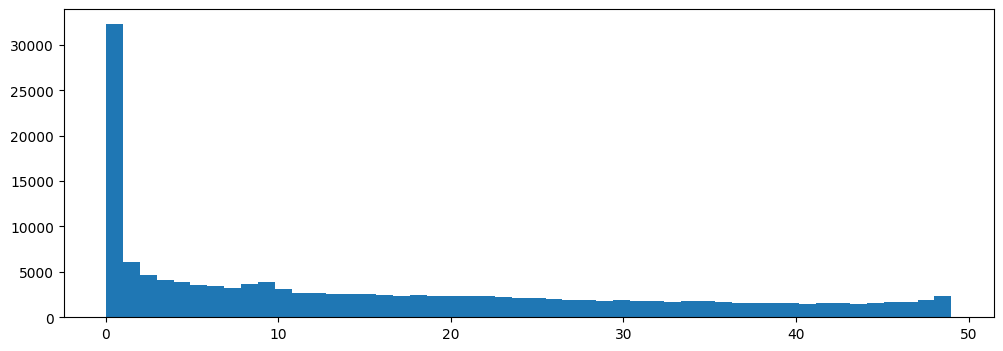

In [52]:
labels = [s.label_idx for s in bc_samples]

plt.figure(figsize=(12,4))
plt.hist(labels, bins=50)
plt.show()

Creating fresh policy...
Starting Behavior Cloning...
Using 2 GPUs
Train samples: 135,000
Val samples:   15,000


BC Epoch 1: 100%|██████████| 528/528 [00:22<00:00, 23.60it/s]


Epoch 01 | loss=3.0272 | train_acc=23.5% | val_acc=27.3%


BC Epoch 2: 100%|██████████| 528/528 [00:20<00:00, 25.32it/s]


Epoch 02 | loss=2.8156 | train_acc=29.0% | val_acc=31.7%


...

Epoch 08 | loss=2.5174 | train_acc=35.4% | val_acc=35.5%


BC Epoch 9: 100%|██████████| 528/528 [00:20<00:00, 25.29it/s]


Epoch 09 | loss=2.4977 | train_acc=35.8% | val_acc=35.6%


BC Epoch 10: 100%|██████████| 528/528 [00:20<00:00, 25.40it/s]


Epoch 10 | loss=2.4865 | train_acc=36.1% | val_acc=35.9%
BC checkpoint saved: /kaggle/working/checkpoints/bc_policy.pt


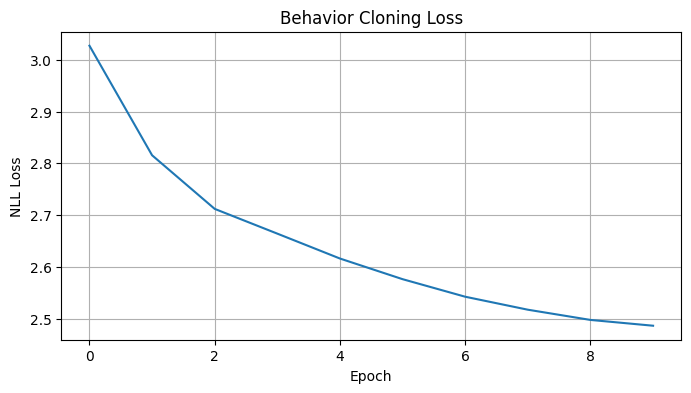

In [82]:
# ============================================================
# CELL 12: BEHAVIOR CLONING TRAINING
# ============================================================

from torch.utils.data import Dataset, DataLoader, random_split

class BCDataset(Dataset):

    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return (
            s.planet_t,
            s.fleet_t,
            s.cand_raw,
            s.label_idx
        )


def bc_collate(batch):

    pts, fts, craws, labels = zip(*batch)

    max_k = max(
        c.shape[0]
        for c in craws
    )

    padded = []

    for c in craws:

        k, d = c.shape

        if k < max_k:

            pad = torch.zeros(
                max_k - k,
                d,
                dtype=c.dtype
            )

            c = torch.cat(
                [c, pad],
                dim=0
            )

        padded.append(c)

    return (
        torch.stack(pts),
        torch.stack(fts),
        torch.stack(padded),
        torch.tensor(
            labels,
            dtype=torch.long
        )
    )


def train_bc(
    policy,
    samples,
    cfg=CFG
):

    dataset = BCDataset(samples)

    n_train = int(
        len(dataset) * 0.9
    )

    n_val = (
        len(dataset)
        - n_train
    )

    train_ds, val_ds = random_split(
        dataset,
        [n_train, n_val],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.BC_BATCH,
        shuffle=True,
        collate_fn=bc_collate,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.BC_BATCH,
        shuffle=False,
        collate_fn=bc_collate,
        num_workers=2,
        pin_memory=True
    )

    optimizer = torch.optim.AdamW(
        policy.parameters(),
        lr=cfg.LR_BC,
        weight_decay=1e-4
    )

    scheduler = (
        torch.optim.lr_scheduler
        .CosineAnnealingLR(
            optimizer,
            T_max=cfg.BC_EPOCHS
        )
    )

    if (
        torch.cuda.device_count() > 1
        and not isinstance(
            policy,
            nn.DataParallel
        )
    ):
        print(
            f'Using {torch.cuda.device_count()} GPUs'
        )
        policy = nn.DataParallel(policy)

    loss_history = []

    print(
        f'Train samples: {len(train_ds):,}'
    )
    print(
        f'Val samples:   {len(val_ds):,}'
    )

    for epoch in range(cfg.BC_EPOCHS):

        # ==========================================
        # TRAIN
        # ==========================================

        policy.train()

        epoch_loss = 0.0
        train_correct = 0
        train_total = 0

        pbar = tqdm(
            train_loader,
            desc=f'BC Epoch {epoch+1}'
        )

        for (
            pt,
            ft,
            craw,
            labels
        ) in pbar:

            pt = pt.to(
                DEVICE,
                non_blocking=True
            )

            ft = ft.to(
                DEVICE,
                non_blocking=True
            )

            craw = craw.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            log_probs, _ = policy(
                pt,
                ft,
                craw
            )

            loss = F.nll_loss(
                log_probs,
                labels
            )

            optimizer.zero_grad()

            loss.backward()

            nn.utils.clip_grad_norm_(
                policy.parameters(),
                cfg.MAX_GRAD_NORM
            )

            optimizer.step()

            epoch_loss += loss.item()

            preds = log_probs.argmax(
                dim=-1
            )

            train_correct += (
                preds == labels
            ).sum().item()

            train_total += labels.size(0)

        scheduler.step()

        avg_loss = (
            epoch_loss
            / len(train_loader)
        )

        train_acc = (
            train_correct
            / train_total
            * 100
        )

        # ==========================================
        # VALIDATION
        # ==========================================

        policy.eval()

        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for (
                pt,
                ft,
                craw,
                labels
            ) in val_loader:

                pt = pt.to(DEVICE)
                ft = ft.to(DEVICE)
                craw = craw.to(DEVICE)
                labels = labels.to(DEVICE)

                log_probs, _ = policy(
                    pt,
                    ft,
                    craw
                )

                preds = log_probs.argmax(
                    dim=-1
                )

                val_correct += (
                    preds == labels
                ).sum().item()

                val_total += labels.size(0)

        val_acc = (
            val_correct
            / val_total
            * 100
        )

        loss_history.append(
            avg_loss
        )

        print(
            f'Epoch {epoch+1:02d} | '
            f'loss={avg_loss:.4f} | '
            f'train_acc={train_acc:.1f}% | '
            f'val_acc={val_acc:.1f}%'
        )

    if isinstance(
        policy,
        nn.DataParallel
    ):
        policy = policy.module

    return (
        policy,
        loss_history
    )


# ============================================================
# TRAIN FROM SCRATCH
# ============================================================

print(
    'Creating fresh policy...'
)

policy = OrbitPolicy(
    CFG
).to(DEVICE)

print(
    'Starting Behavior Cloning...'
)

policy, bc_losses = train_bc(
    policy,
    bc_samples,
    CFG
)

# ============================================================
# SAVE
# ============================================================

os.makedirs(
    '/kaggle/working/checkpoints',
    exist_ok=True
)

BC_CKPT = (
    '/kaggle/working/checkpoints/'
    'bc_policy.pt'
)

torch.save(
    policy.state_dict(),
    BC_CKPT
)

print(
    f'BC checkpoint saved: {BC_CKPT}'
)

# ============================================================
# PLOT
# ============================================================

plt.figure(
    figsize=(8,4)
)

plt.plot(
    bc_losses
)

plt.title(
    'Behavior Cloning Loss'
)

plt.xlabel(
    'Epoch'
)

plt.ylabel(
    'NLL Loss'
)

plt.grid(True)

plt.show()

In [85]:
# ============================================================
# CELL 13: PPO ROLLOUT BUFFER
# ============================================================

@dataclass
class Transition:
    planet_t:   torch.Tensor
    fleet_t:    torch.Tensor
    cand_raw:   torch.Tensor
    action_idx: int
    log_prob:   float
    value:      float
    reward:     float
    done:       bool


class RolloutBuffer:
    def __init__(self):
        self.transitions: List[Transition] = []

    def add(self, t: Transition):
        self.transitions.append(t)

    def clear(self):
        self.transitions = []

    def __len__(self):
        return len(self.transitions)

    def compute_gae(self, last_value: float, cfg: Config = CFG
                    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor,
                               torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Returns: planet_ts, fleet_ts, cand_raws, action_idxs,
                 old_log_probs, advantages, returns
        (all padded to uniform K dimension)
        """
        rewards  = [t.reward  for t in self.transitions]
        values   = [t.value   for t in self.transitions]
        dones    = [t.done    for t in self.transitions]

        # GAE
        advantages = [0.0] * len(self.transitions)
        gae = 0.0
        next_val = last_value

        for i in reversed(range(len(self.transitions))):
            mask   = 0.0 if dones[i] else 1.0
            delta  = rewards[i] + cfg.GAMMA * next_val * mask - values[i]
            gae    = delta + cfg.GAMMA * cfg.GAE_LAMBDA * mask * gae
            advantages[i] = gae
            next_val = values[i]

        advantages = torch.tensor(advantages, dtype=torch.float32)
        returns    = advantages + torch.tensor(values, dtype=torch.float32)
        # Normalize advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # Stack tensors (pad cand_raw to max K)
        max_k = max(t.cand_raw.shape[0] for t in self.transitions)
        planet_ts  = torch.stack([t.planet_t  for t in self.transitions])
        fleet_ts   = torch.stack([t.fleet_t   for t in self.transitions])

        cand_raws_padded = []
        for t in self.transitions:
            c = t.cand_raw
            k, d = c.shape
            if k < max_k:
                c = torch.cat([c, torch.zeros(max_k-k, d)], dim=0)
            cand_raws_padded.append(c)
        cand_raws = torch.stack(cand_raws_padded)

        action_idxs  = torch.tensor([t.action_idx for t in self.transitions],
                                    dtype=torch.long)
        old_log_probs = torch.tensor([t.log_prob  for t in self.transitions],
                                     dtype=torch.float32)

        return (planet_ts, fleet_ts, cand_raws,
                action_idxs, old_log_probs, advantages, returns)


print('RolloutBuffer ✓')

RolloutBuffer ✓


In [86]:
# ============================================================
# CELL 14: PPO UPDATE
# ============================================================

def ppo_update(policy: OrbitPolicy,
               optimizer: torch.optim.Optimizer,
               buffer: RolloutBuffer,
               last_value: float,
               cfg: Config = CFG) -> Dict[str, float]:

    (planet_ts, fleet_ts, cand_raws,
     action_idxs, old_log_probs,
     advantages, returns) = buffer.compute_gae(last_value, cfg)

    N = len(planet_ts)
    metrics = defaultdict(float)

    for _ in range(cfg.PPO_EPOCHS):
        idx_perm = torch.randperm(N)

        for start in range(0, N, cfg.PPO_BATCH):
            idx = idx_perm[start:start + cfg.PPO_BATCH]

            pt_b   = planet_ts[idx].to(DEVICE)
            ft_b   = fleet_ts[idx].to(DEVICE)
            cr_b   = cand_raws[idx].to(DEVICE)
            a_b    = action_idxs[idx].to(DEVICE)
            olp_b  = old_log_probs[idx].to(DEVICE)
            adv_b  = advantages[idx].to(DEVICE)
            ret_b  = returns[idx].to(DEVICE)

            log_probs, values = policy(pt_b, ft_b, cr_b)

            # Gather log prob of taken actions
            new_lp = log_probs.gather(1, a_b.unsqueeze(1)).squeeze(1)

            # PPO clipped objective
            ratio   = torch.exp(new_lp - olp_b)
            surr1   = ratio * adv_b
            surr2   = ratio.clamp(1.0 - cfg.PPO_CLIP,
                                  1.0 + cfg.PPO_CLIP) * adv_b
            pol_loss = -torch.min(surr1, surr2).mean()

            # Value loss
            val_loss = F.mse_loss(values, ret_b)

            # Entropy bonus
            entropy  = -(log_probs.exp() * log_probs).sum(dim=-1).mean()

            loss = pol_loss + cfg.VALUE_COEF * val_loss - cfg.ENTROPY_COEF * entropy

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(policy.parameters(), cfg.MAX_GRAD_NORM)
            optimizer.step()

            metrics['pol_loss']  += pol_loss.item()
            metrics['val_loss']  += val_loss.item()
            metrics['entropy']   += entropy.item()

    n_updates = max(1, cfg.PPO_EPOCHS * math.ceil(N / cfg.PPO_BATCH))
    return {k: v / n_updates for k, v in metrics.items()}


print('PPO update function ✓')

PPO update function ✓


In [87]:
# ============================================================
# CELL 15: CHECKPOINT POOL + PFSP SAMPLING
# ============================================================

class CheckpointPool:
    """
    Maintains pool of past policies + win-rate tracking for PFSP.
    """
    def __init__(self, cfg: Config = CFG, save_dir: str = '/kaggle/working/checkpoints'):
        self.cfg      = cfg
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)
        self.pool: List[Dict] = []   # [{state_dict, wins, games, elo}]

    def add(self, policy: OrbitPolicy, elo: float = 1000.0):
        if len(self.pool) >= self.cfg.POOL_SIZE:
            # Remove weakest
            self.pool.sort(key=lambda x: x['elo'])
            self.pool.pop(0)

        idx = len(self.pool)
        path = os.path.join(self.save_dir, f'ckpt_{idx:04d}.pt')
        torch.save(policy.state_dict(), path)
        self.pool.append({'path': path, 'wins': 0, 'games': 0, 'elo': elo})

    def sample_opponent(self, current_elo: float) -> OrbitPolicy:
        """PFSP: sample opponent weighted toward close-to-current ELO."""
        if not self.pool:
            opp = OrbitPolicy(self.cfg).to(DEVICE)
            return opp

        # P(opponent i) ∝ f(winrate_i)  where f = prioritised
        winrates = []
        for p in self.pool:
            wr = p['wins'] / max(p['games'], 1)
            winrates.append(wr)

        # PFSP weighting: prefer opponents with winrate close to 0.5
        weights = np.array([abs(wr - 0.5) ** (-self.cfg.PFSP_ALPHA)
                            if wr not in [0.0, 1.0] else 0.1
                            for wr in winrates], dtype=float)
        weights /= weights.sum()

        chosen = np.random.choice(self.pool, p=weights)
        opp = OrbitPolicy(self.cfg).to(DEVICE)
        opp.load_state_dict(torch.load(chosen['path'], map_location=DEVICE))
        opp.eval()
        return opp

    def update_result(self, opp_idx: int, won: bool):
        if 0 <= opp_idx < len(self.pool):
            self.pool[opp_idx]['games'] += 1
            if won:
                self.pool[opp_idx]['wins'] += 1


print('CheckpointPool ✓')

CheckpointPool ✓


In [88]:
# ============================================================
# CELL 16: SELF-PLAY ENGINE
# ============================================================

def run_episode(policy1: OrbitPolicy,
                policy2: OrbitPolicy,
                buffer: Optional[RolloutBuffer] = None,
                collect_for: int = 1,
                cfg: Config = CFG) -> Tuple[int, list]:
    # ── Tự tạo env bên trong, không nhận từ ngoài
    env = make_env()
    env.reset()
    pending = []

    while not env.done:
        actions = []
        for player_idx in [0, 1]:
            try:
                state   = env.state[player_idx]
                obs_raw = state['observation']
                obs     = kaggle_obs_to_pipeline(obs_raw)
            except Exception:
                actions.append([])
                continue

            policy = policy1 if player_idx == 0 else policy2
            cands  = generate_candidates(obs, cfg)

            if not cands:
                actions.append([])
                continue

            pt, ft = parse_obs(obs, cfg)
            cr_list = []
            for c in cands:
                ff = fast_simulate(obs, c, cfg.SIM_TURNS)
                cr_list.append(encode_candidate_raw(c, obs, ff, cfg))
            cand_raw = torch.stack(cr_list)

            policy.eval()
            with torch.no_grad():
                lp_all, val = policy(
                    pt.unsqueeze(0).to(DEVICE),
                    ft.unsqueeze(0).to(DEVICE),
                    cand_raw.unsqueeze(0).to(DEVICE))
                lp_all = lp_all.squeeze(0)
                val    = val.squeeze(0).item()

            dist = Categorical(logits=lp_all)
            idx  = dist.sample().item()

            actions.append([cands[idx].to_action()])  # list of moves

            if player_idx == 0 and collect_for == 1 and buffer is not None:
                pending.append(Transition(
                    planet_t=pt, fleet_t=ft, cand_raw=cand_raw,
                    action_idx=idx, log_prob=lp_all[idx].item(),
                    value=val, reward=0.0, done=False))

        env.step(actions)

    # Kết quả
    final   = env.steps[-1]
    r0      = final[0].reward or 0
    r1      = final[1].reward or 0
    winner  = 1 if r0 > r1 else (2 if r1 > r0 else -1)
    reward_p1 = 1.0 if winner == 1 else (-1.0 if winner == 2 else 0.0)

    if buffer is not None and pending:
        for i, t in enumerate(pending):
            is_last = (i == len(pending) - 1)
            pending[i] = Transition(
                planet_t=t.planet_t, fleet_t=t.fleet_t,
                cand_raw=t.cand_raw, action_idx=t.action_idx,
                log_prob=t.log_prob, value=t.value,
                reward=reward_p1 if is_last else 0.0,
                done=is_last)
        for tr in pending:
            buffer.add(tr)

    return winner, pending


print('Self-play engine ✓')

Self-play engine ✓


In [17]:
# ============================================================
# CELL 17: SELF-PLAY PPO TRAINING LOOP
# ============================================================

def selfplay_train(policy: OrbitPolicy,
                   cfg: Config = CFG,
                   resume_from: Optional[str] = None):

    if resume_from and os.path.exists(resume_from):
        policy.load_state_dict(torch.load(resume_from, map_location=DEVICE))
        print(f'Loaded checkpoint: {resume_from}')

    optimizer = torch.optim.AdamW(policy.parameters(), lr=cfg.LR_PPO,
                                  weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg.SELFPLAY_ITERS)

    pool   = CheckpointPool(cfg)
    pool.add(copy.deepcopy(policy), elo=1000.0)
    buffer = RolloutBuffer()

    win_history  = []
    loss_history = {'pol': [], 'val': [], 'ent': []}
    elo          = 1000.0
    best_elo     = elo
    K_ELO        = 32

    for iteration in range(1, cfg.SELFPLAY_ITERS + 1):
        policy.train()
        buffer.clear()

        opponent = pool.sample_opponent(elo)
        opponent.eval()

        wins = 0
        for g in range(cfg.GAMES_PER_ITER):
            # ── THAY: bỏ env argument, run_episode tự tạo kaggle env bên trong
            winner, _ = run_episode(policy, opponent, buffer,
                                    collect_for=1, cfg=cfg)
            wins += int(winner == 1)

        winrate = wins / cfg.GAMES_PER_ITER
        win_history.append(winrate)

        opp_elo  = pool.pool[-1]['elo'] if pool.pool else 1000.0
        expected = 1 / (1 + 10 ** ((opp_elo - elo) / 400))
        elo     += K_ELO * (winrate - expected)

        if len(buffer) >= cfg.PPO_BATCH:
            metrics = ppo_update(policy, optimizer, buffer, 0.0, cfg)
            loss_history['pol'].append(metrics['pol_loss'])
            loss_history['val'].append(metrics['val_loss'])
            loss_history['ent'].append(metrics['entropy'])

        scheduler.step()

        if iteration % 50 == 0:
            pool.add(copy.deepcopy(policy), elo=elo)
            torch.save(policy.state_dict(),
                       f'/kaggle/working/checkpoints/selfplay_{iteration:04d}.pt')

        if elo > best_elo:
            best_elo = elo
            torch.save(policy.state_dict(),
                       '/kaggle/working/checkpoints/best_policy.pt')

        if iteration % 25 == 0:
            recent_wr = np.mean(win_history[-25:])
            print(f'[Iter {iteration:4d}] ELO={elo:.0f}  WR={recent_wr:.2f}  '
                  f'buf={len(buffer)}  best_ELO={best_elo:.0f}')

    return policy, win_history, loss_history


print('Self-play training loop ready ✓')
print('Starting self-play training...')
policy, win_hist, loss_hist = selfplay_train(
    policy, CFG,
    resume_from='/kaggle/working/checkpoints/bc_policy.pt'
)

Self-play training loop ready ✓
Starting self-play training...
Loaded checkpoint: /kaggle/working/checkpoints/bc_policy.pt
[Iter   25] ELO=1029  WR=0.51  buf=1996  best_ELO=1029
[Iter   50] ELO=1153  WR=0.78  buf=1996  best_ELO=1160
[Iter   75] ELO=1298  WR=0.79  buf=1996  best_ELO=1306
[Iter  100] ELO=1343  WR=0.77  buf=1996  best_ELO=1343
[Iter  125] ELO=1491  WR=0.77  buf=1996  best_ELO=1491
[Iter  150] ELO=1556  WR=0.82  buf=1996  best_ELO=1556
[Iter  175] ELO=1650  WR=0.72  buf=1996  best_ELO=1670
[Iter  200] ELO=1695  WR=0.73  buf=1996  best_ELO=1701
[Iter  225] ELO=1792  WR=0.70  buf=1996  best_ELO=1793
[Iter  250] ELO=1839  WR=0.72  buf=1996  best_ELO=1839
[Iter  275] ELO=1877  WR=0.59  buf=1996  best_ELO=1885
[Iter  300] ELO=1973  WR=0.74  buf=1996  best_ELO=1973


In [ ]:
# ============================================================
# CELL 17: SELF-PLAY PPO TRAINING LOOP
# ============================================================

def selfplay_train(policy: OrbitPolicy,
                   cfg: Config = CFG,
                   resume_from: Optional[str] = None):

    if resume_from and os.path.exists(resume_from):
        policy.load_state_dict(torch.load(resume_from, map_location=DEVICE))
        print(f'Loaded checkpoint: {resume_from}')

    optimizer = torch.optim.AdamW(policy.parameters(), lr=cfg.LR_PPO,
                                  weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg.SELFPLAY_ITERS)

    pool   = CheckpointPool(cfg)
    pool.add(copy.deepcopy(policy), elo=1000.0)
    buffer = RolloutBuffer()

    win_history  = []
    loss_history = {'pol': [], 'val': [], 'ent': []}
    elo          = 1000.0
    best_elo     = elo
    K_ELO        = 32

    for iteration in range(1, cfg.SELFPLAY_ITERS + 1):
        policy.train()
        buffer.clear()

        opponent = pool.sample_opponent(elo)
        opponent.eval()

        wins = 0
        for g in range(cfg.GAMES_PER_ITER):
            # ── THAY: bỏ env argument, run_episode tự tạo kaggle env bên trong
            winner, _ = run_episode(policy, opponent, buffer,
                                    collect_for=1, cfg=cfg)
            wins += int(winner == 1)

        winrate = wins / cfg.GAMES_PER_ITER
        win_history.append(winrate)

        opp_elo  = pool.pool[-1]['elo'] if pool.pool else 1000.0
        expected = 1 / (1 + 10 ** ((opp_elo - elo) / 400))
        elo     += K_ELO * (winrate - expected)

        if len(buffer) >= cfg.PPO_BATCH:
            metrics = ppo_update(policy, optimizer, buffer, 0.0, cfg)
            loss_history['pol'].append(metrics['pol_loss'])
            loss_history['val'].append(metrics['val_loss'])
            loss_history['ent'].append(metrics['entropy'])

        scheduler.step()

        if iteration % 50 == 0:
            pool.add(copy.deepcopy(policy), elo=elo)
            torch.save(policy.state_dict(),
                       f'/kaggle/working/checkpoints/selfplay_{iteration:04d}.pt')

        if elo > best_elo:
            best_elo = elo
            torch.save(policy.state_dict(),
                       '/kaggle/working/checkpoints/best_policy.pt')

        if iteration % 25 == 0:
            recent_wr = np.mean(win_history[-25:])
            print(f'[Iter {iteration:4d}] ELO={elo:.0f}  WR={recent_wr:.2f}  '
                  f'buf={len(buffer)}  best_ELO={best_elo:.0f}')

    return policy, win_history, loss_history


print('Self-play training loop ready ✓')
print('Starting self-play training...')
policy, win_hist, loss_hist = selfplay_train(
    policy, CFG,
    resume_from='/kaggle/working/checkpoints/bc_policy.pt'
)

Self-play training loop ready ✓
Starting self-play training...
Loaded checkpoint: /kaggle/working/checkpoints/bc_policy.pt
[Iter   25] ELO=1000  WR=0.48  buf=1792  best_ELO=1012


In [19]:
# ============================================================
# CELL 18: BRADLEY-TERRY RATING + CHECKPOINT SELECTION
# ============================================================

def bradley_terry(win_matrix: np.ndarray,
                  n_iters: int = 100,
                  tol: float = 1e-6) -> np.ndarray:
    """
    win_matrix[i,j] = number of times i beat j
    Returns: ratings array [n_players]
    """
    n = win_matrix.shape[0]
    ratings = np.ones(n)

    for _ in range(n_iters):
        new_ratings = np.zeros(n)

        for i in range(n):
            wins_i = win_matrix[i].sum()

            denom = 0.0
            for j in range(n):
                if i == j:
                    continue

                denom += (
                    win_matrix[i, j] + win_matrix[j, i]
                ) / (ratings[i] + ratings[j] + 1e-12)

            new_ratings[i] = wins_i / (denom + 1e-12)

        new_ratings /= (new_ratings.mean() + 1e-12)

        if np.max(np.abs(new_ratings - ratings)) < tol:
            ratings = new_ratings
            break

        ratings = new_ratings

    return ratings


def evaluate_checkpoints(
    ckpt_paths: List[str],
    n_games: int = 20,
    cfg: Config = CFG
) -> int:
    """
    Round-robin tournament between checkpoints.
    Returns index of best checkpoint.
    """

    n = len(ckpt_paths)

    if n == 0:
        return 0

    print(f'Loading {n} checkpoints...')

    policies = []

    for path in ckpt_paths:

        policy = OrbitPolicy(cfg).to(DEVICE)

        if os.path.exists(path):
            state_dict = torch.load(
                path,
                map_location=DEVICE
            )
            policy.load_state_dict(state_dict)

        policy.eval()
        policies.append(policy)

    wins = np.zeros((n, n), dtype=np.float32)

    total_matches = n * (n - 1) * n_games
    match_counter = 0

    print(
        f'Running tournament: '
        f'{n} checkpoints × {n_games} games'
    )

    for i in range(n):

        for j in range(n):

            if i == j:
                continue

            for g in range(n_games):

                match_counter += 1

                if match_counter % 20 == 0:
                    print(
                        f'Progress: '
                        f'{match_counter}/{total_matches}'
                    )

                winner, _ = run_episode(
                    policies[i],
                    policies[j],
                    buffer=None,
                    collect_for=-1,
                    cfg=cfg
                )

                if winner == 1:
                    wins[i, j] += 1

                elif winner == 2:
                    wins[j, i] += 1

    ratings = bradley_terry(wins)

    best_idx = int(np.argmax(ratings))

    print("\nBradley-Terry ratings:")
    print("=" * 70)

    for idx, (path, rating) in enumerate(
        zip(ckpt_paths, ratings)
    ):

        marker = " ← BEST" if idx == best_idx else ""

        print(
            f"[{idx}] "
            f"{os.path.basename(path):30s} "
            f"rating={rating:.4f}"
            f"{marker}"
        )

    print("=" * 70)

    return best_idx


# ============================================================
# FIND AVAILABLE CHECKPOINTS
# ============================================================

ckpt_dir = "/kaggle/working/checkpoints"

ckpt_paths = sorted([
    os.path.join(ckpt_dir, f)
    for f in os.listdir(ckpt_dir)
    if (
        f.endswith(".pt")
        and "selfplay" in f
    )
])

best_path = os.path.join(
    ckpt_dir,
    "best_policy.pt"
)

if (
    os.path.exists(best_path)
    and best_path not in ckpt_paths
):
    ckpt_paths.append(best_path)

print(f"Found {len(ckpt_paths)} checkpoints")

for p in ckpt_paths:
    print(" -", os.path.basename(p))

# ============================================================
# SELECT BEST CHECKPOINT
# ============================================================

if len(ckpt_paths) == 0:

    raise RuntimeError(
        "No checkpoints found."
    )

elif len(ckpt_paths) == 1:

    FINAL_CKPT = ckpt_paths[0]

    print(
        f"\nOnly one checkpoint found."
        f"\nSelected: {FINAL_CKPT}"
    )

else:

    print(
        f"\nEvaluating {len(ckpt_paths)} checkpoints..."
    )

    best_idx = evaluate_checkpoints(
        ckpt_paths,
        n_games=10,
        cfg=CFG
    )

    FINAL_CKPT = ckpt_paths[best_idx]

print(
    f"\nFinal checkpoint selected:"
    f"\n{FINAL_CKPT}"
)

Found 7 checkpoints
 - selfplay_0050.pt
 - selfplay_0100.pt
 - selfplay_0150.pt
 - selfplay_0200.pt
 - selfplay_0250.pt
 - selfplay_0300.pt
 - best_policy.pt

Evaluating 7 checkpoints...
Loading 7 checkpoints...
Running tournament: 7 checkpoints × 10 games
Progress: 20/420
Progress: 40/420
Progress: 60/420
Progress: 80/420
Progress: 100/420
Progress: 120/420
Progress: 140/420
Progress: 160/420
Progress: 180/420
Progress: 200/420
Progress: 220/420
Progress: 240/420
Progress: 260/420
Progress: 280/420
Progress: 300/420
Progress: 320/420
Progress: 340/420
Progress: 360/420
Progress: 380/420
Progress: 400/420
Progress: 420/420

Bradley-Terry ratings:
[0] selfplay_0050.pt               rating=0.6714
[1] selfplay_0100.pt               rating=0.5585
[2] selfplay_0150.pt               rating=1.2106
[3] selfplay_0200.pt               rating=1.4492 ← BEST
[4] selfplay_0250.pt               rating=1.0450
[5] selfplay_0300.pt               rating=1.1081
[6] best_policy.pt                 rating=0.

In [21]:
# ============================================================
# CELL 19: OFFLINE EVALUATION vs HEURISTIC
# ============================================================

def evaluate_vs_heuristic(
    policy: OrbitPolicy,
    n_games: int = 200,
    cfg: Config = CFG
) -> Dict:

    hbot = HeuristicBot()

    wins   = 0
    draws  = 0
    losses = 0

    game_lengths = []

    policy.eval()

    for g in tqdm(range(n_games), desc="Evaluating vs heuristic"):

        env = make_env(seed=g)
        env.reset()

        policy_is_p1 = (g % 2 == 0)

        turn_count = 0

        while not env.done:

            actions = []

            for player_idx in [0, 1]:

                try:
                    state   = env.state[player_idx]
                    raw_obs = state["observation"]
                    obs     = kaggle_obs_to_pipeline(raw_obs)

                except Exception:
                    actions.append([])
                    continue

                # --------------------------------------------------
                # Policy side
                # --------------------------------------------------
                if policy_is_p1:

                    if player_idx == 0:
                        action, _, _ = policy.act(
                            obs,
                            cfg,
                            greedy=True
                        )
                        actions.append(
                            [] if action is None else [action]
                        )

                    else:
                        actions.append(
                            hbot.act(obs)
                        )

                else:

                    if player_idx == 0:
                        actions.append(
                            hbot.act(obs)
                        )

                    else:
                        action, _, _ = policy.act(
                            obs,
                            cfg,
                            greedy=True
                        )
                        actions.append(
                            [] if action is None else [action]
                        )

            env.step(actions)

            turn_count += 1

        final = env.steps[-1]

        r0 = final[0].reward or 0
        r1 = final[1].reward or 0

        if r0 > r1:
            winner = 1
        elif r1 > r0:
            winner = 2
        else:
            winner = -1

        policy_player = 1 if policy_is_p1 else 2

        game_lengths.append(turn_count)

        if winner == policy_player:
            wins += 1

        elif winner == -1:
            draws += 1

        else:
            losses += 1

    wr = wins / n_games
    dr = draws / n_games
    lr = losses / n_games

    avg_len = float(np.mean(game_lengths))

    print(f"\n=== Evaluation vs Heuristic ({n_games} games) ===")
    print(f"Wins:   {wins:4d} ({wr*100:.2f}%)")
    print(f"Draws:  {draws:4d} ({dr*100:.2f}%)")
    print(f"Losses: {losses:4d} ({lr*100:.2f}%)")
    print(f"Avg game length: {avg_len:.1f}")

    # --------------------------------------------------
    # ELO estimate
    # --------------------------------------------------

    HEURISTIC_ELO = 800

    if wr >= 0.999:
        est_elo = HEURISTIC_ELO + 400

    elif wr <= 0.001:
        est_elo = HEURISTIC_ELO - 400

    else:
        est_elo = (
            HEURISTIC_ELO
            - 400 * math.log10((1 - wr) / wr)
        )

    print(f"Estimated ELO: {est_elo:.0f}")

    if est_elo >= 1200:
        print("Target ELO 1200: ✓ REACHED")
    else:
        print(
            f"Target ELO 1200: gap={1200-est_elo:.0f}"
        )

    return {
        "wins": wins,
        "draws": draws,
        "losses": losses,
        "winrate": wr,
        "elo": est_elo,
        "avg_len": avg_len
    }


# ============================================================
# LOAD BEST MODEL
# ============================================================

final_policy = OrbitPolicy(CFG).to(DEVICE)

if os.path.exists(FINAL_CKPT):

    final_policy.load_state_dict(
        torch.load(
            FINAL_CKPT,
            map_location=DEVICE
        )
    )

    print(f"Loaded {FINAL_CKPT}")

else:
    raise FileNotFoundError(FINAL_CKPT)


# ============================================================
# RUN EVALUATION
# ============================================================

eval_results = evaluate_vs_heuristic(
    final_policy,
    n_games=200,
    cfg=CFG
)

print("\nResults:")
print(eval_results)

Loaded /kaggle/working/checkpoints/selfplay_0200.pt


Evaluating vs heuristic: 100%|██████████| 200/200 [25:33<00:00,  7.67s/it]


=== Evaluation vs Heuristic (200 games) ===
Wins:     72 (36.00%)
Draws:     0 (0.00%)
Losses:  128 (64.00%)
Avg game length: 412.3
Estimated ELO: 700
Target ELO 1200: gap=500

Results:
{'wins': 72, 'draws': 0, 'losses': 128, 'winrate': 0.36, 'elo': 700.0490107133601, 'avg_len': 412.285}


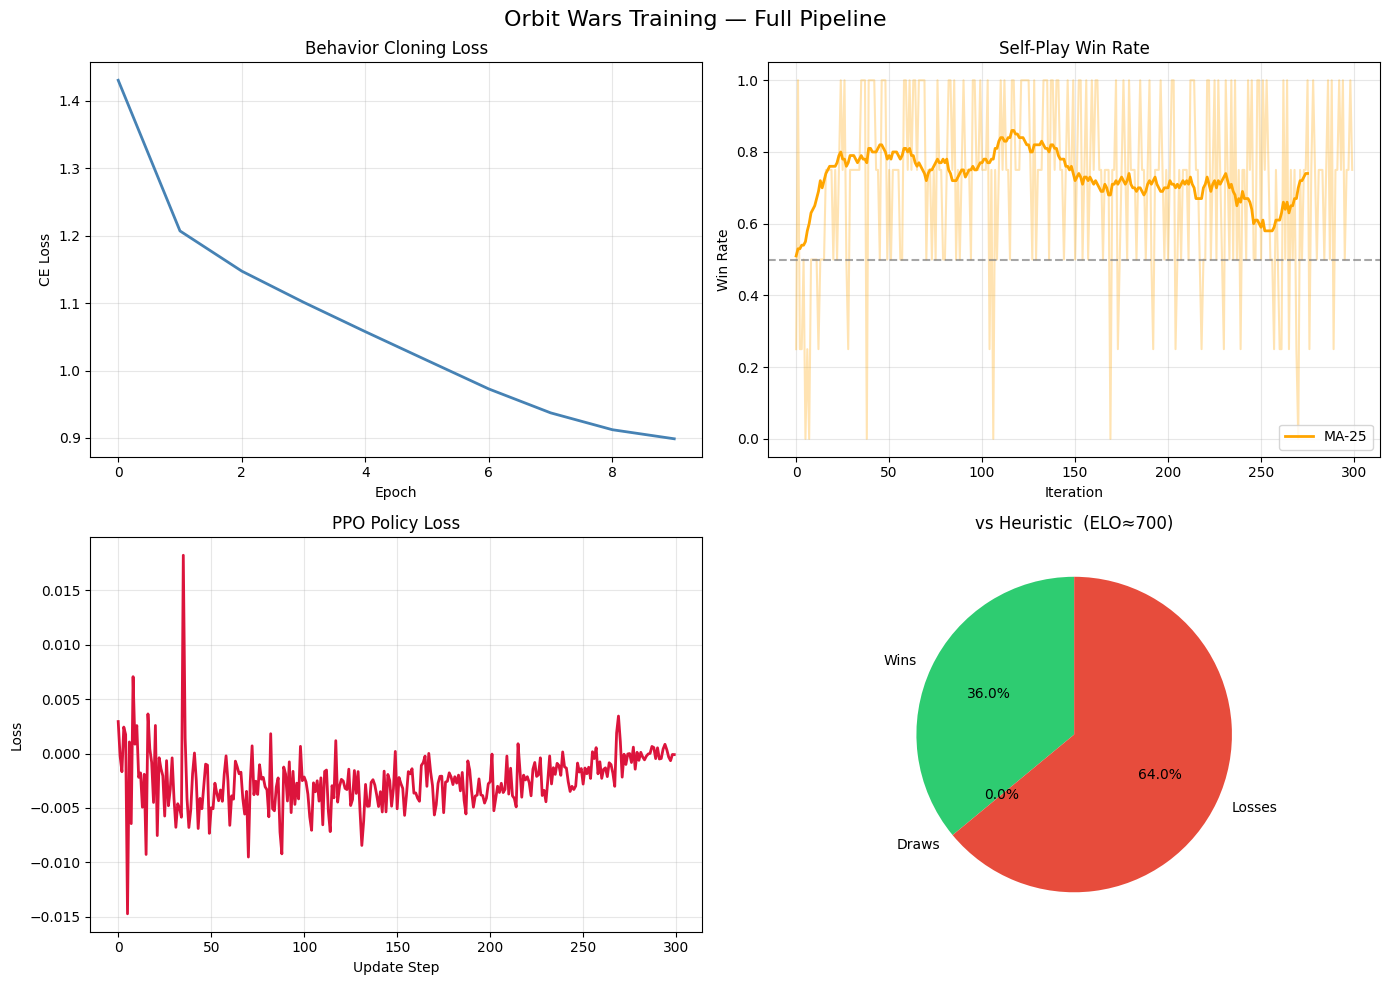

Plots saved ✓


In [22]:
# ============================================================
# CELL 20: TRAINING PLOTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Orbit Wars Training — Full Pipeline', fontsize=16)

# BC loss
axes[0, 0].plot(bc_losses, color='steelblue', linewidth=2)
axes[0, 0].set_title('Behavior Cloning Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('CE Loss')
axes[0, 0].grid(True, alpha=0.3)

# Self-play winrate
if win_hist:
    window = 25
    smoothed = np.convolve(win_hist, np.ones(window)/window, mode='valid')
    axes[0, 1].plot(win_hist, alpha=0.3, color='orange')
    axes[0, 1].plot(smoothed, color='orange', linewidth=2, label=f'MA-{window}')
    axes[0, 1].axhline(0.5, linestyle='--', color='gray', alpha=0.7)
    axes[0, 1].set_title('Self-Play Win Rate')
    axes[0, 1].set_xlabel('Iteration')
    axes[0, 1].set_ylabel('Win Rate')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

# PPO policy loss
if loss_hist['pol']:
    axes[1, 0].plot(loss_hist['pol'], color='crimson', linewidth=2)
    axes[1, 0].set_title('PPO Policy Loss')
    axes[1, 0].set_xlabel('Update Step')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].grid(True, alpha=0.3)

# Evaluation summary
labels = ['Wins', 'Draws', 'Losses']
sizes  = [eval_results['wins'], eval_results['draws'], eval_results['losses']]
colors = ['#2ecc71', '#95a5a6', '#e74c3c']
axes[1, 1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
               startangle=90)
axes[1, 1].set_title(f'vs Heuristic  (ELO≈{eval_results["elo"]:.0f})')

plt.tight_layout()
plt.savefig('/kaggle/working/training_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plots saved ✓')

In [24]:
# ============================================================
# CELL 21: INFERENCE BENCHMARK
# ============================================================

def benchmark_inference(
    policy: OrbitPolicy,
    n_trials: int = 100,
    cfg: Config = CFG
) -> float:

    env = make_env(seed=0)
    env.reset()

    raw_obs = env.state[0]["observation"]
    obs = kaggle_obs_to_pipeline(raw_obs)

    policy.eval()

    times = []

    with torch.no_grad():

        for _ in range(n_trials):

            t0 = time.perf_counter()

            _action, _logp, _value = policy.act(
                obs,
                cfg,
                greedy=True
            )

            times.append(
                (time.perf_counter() - t0) * 1000
            )

    times = np.asarray(times)

    mean_t = times.mean()
    p50 = np.percentile(times, 50)
    p95 = np.percentile(times, 95)
    p99 = np.percentile(times, 99)

    print(f"\nInference timing ({n_trials} trials)")
    print(f"Mean : {mean_t:.2f} ms")
    print(f"P50  : {p50:.2f} ms")
    print(f"P95  : {p95:.2f} ms")
    print(f"P99  : {p99:.2f} ms")

    if p99 < cfg.INFERENCE_MS:
        print(
            f"Target {cfg.INFERENCE_MS} ms : ✓ OK"
        )
    else:
        print(
            f"Target {cfg.INFERENCE_MS} ms : ✗ TOO SLOW"
        )

    return float(mean_t)


benchmark_inference(final_policy)


Inference timing (100 trials)
Mean : 3.79 ms
P50  : 3.74 ms
P95  : 4.10 ms
P99  : 5.47 ms
Target 45 ms : ✓ OK


3.786643939820351

In [30]:
ckpt = torch.load(FINAL_CKPT, map_location="cpu")

for k, v in ckpt.items():
    if "planet_enc.net.0.weight" in k:
        print(k, v.shape)

    if "fleet_enc.net.0.weight" in k:
        print(k, v.shape)

state_enc.obj_enc.planet_enc.net.0.weight torch.Size([64, 21])
state_enc.obj_enc.fleet_enc.net.0.weight torch.Size([64, 20])


In [31]:
# ============================================================
# CELL 22: SUBMISSION FILE
# ============================================================
SUBMISSION_CODE = '''
import math, os
from typing import List, Dict, Optional
from dataclasses import dataclass, field
from collections import defaultdict
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

class Config:
    MAP_W=100; MAP_H=100; N_PLANETS=32; MAX_FLEETS=30
    PLANET_FEAT=6; FLEET_FEAT=5; D_MODEL=128; N_HEADS=8; N_LAYERS=4
    MAX_CANDIDATES=50; SIM_TURNS=8; FUTURE_DIM=10; CAND_RAW_DIM=32

CFG = Config()
DEVICE = torch.device("cpu")

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dims, out_dim, act=nn.GELU):
        super().__init__()
        layers = []; prev = in_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), act(), nn.LayerNorm(h)]; prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class ObjectEncoder(nn.Module):
    def __init__(self, cfg=CFG):
        super().__init__()
        self.owner_emb  = nn.Embedding(3, 16)
        self.planet_enc = MLP(cfg.PLANET_FEAT - 1 + 16, [64], cfg.D_MODEL)
        self.fleet_enc  = MLP(cfg.FLEET_FEAT  - 1 + 16, [64], cfg.D_MODEL)
        self.cls_token  = nn.Parameter(torch.randn(1, 1, cfg.D_MODEL))
    def forward(self, pt, ft):
        if pt.dim() == 2: pt = pt.unsqueeze(0); ft = ft.unsqueeze(0)
        B = pt.shape[0]
        poi = (pt[...,0]*2).long().clamp(0,2)
        foi = (ft[...,0]*2).long().clamp(0,2)
        pf  = torch.cat([pt[...,1:], self.owner_emb(poi)], dim=-1)
        ff  = torch.cat([ft[...,1:], self.owner_emb(foi)], dim=-1)
        cls = self.cls_token.expand(B,-1,-1)
        return torch.cat([cls, self.planet_enc(pf), self.fleet_enc(ff)], dim=1)

class StateEncoder(nn.Module):
    def __init__(self, cfg=CFG):
        super().__init__()
        self.obj_enc = ObjectEncoder(cfg)
        el = nn.TransformerEncoderLayer(d_model=cfg.D_MODEL, nhead=cfg.N_HEADS,
            dim_feedforward=cfg.D_MODEL*4, dropout=0.0,
            batch_first=True, norm_first=False)
        self.transformer = nn.TransformerEncoder(el, num_layers=cfg.N_LAYERS)
    def forward(self, pt, ft):
        return self.transformer(self.obj_enc(pt, ft))[:, 0, :]

class CandidateEncoder(nn.Module):
    def __init__(self, cfg=CFG):
        super().__init__()
        self.net = MLP(cfg.CAND_RAW_DIM, [64], cfg.D_MODEL)
    def forward(self, x): return self.net(x)

class ActionScoringNetwork(nn.Module):
    def __init__(self, cfg=CFG):
        super().__init__()
        self.scorer = MLP(cfg.D_MODEL*2, [128,64], 1)
    def forward(self, se, ce):
        if se.dim()==1: se=se.unsqueeze(0); ce=ce.unsqueeze(0); sq=True
        else: sq=False
        B,K,d = ce.shape
        scores = self.scorer(torch.cat([se.unsqueeze(1).expand(B,K,d), ce], dim=-1)).squeeze(-1)
        return scores.squeeze(0) if sq else scores

class ValueHead(nn.Module):
    def __init__(self, cfg=CFG):
        super().__init__()
        self.net = MLP(cfg.D_MODEL, [64], 1)
    def forward(self, x): return self.net(x).squeeze(-1)

class OrbitPolicy(nn.Module):
    def __init__(self, cfg=CFG):
        super().__init__()
        self.state_enc  = StateEncoder(cfg)
        self.cand_enc   = CandidateEncoder(cfg)
        self.scorer     = ActionScoringNetwork(cfg)
        self.value_head = ValueHead(cfg)
    def forward(self, pt, ft, cr):
        se = self.state_enc(pt, ft)
        ce = self.cand_enc(cr)
        return F.log_softmax(self.scorer(se, ce), dim=-1), self.value_head(se)

@dataclass
class Candidate:
    source:      int
    angle:       float
    ships:       float
    action_type: str
    target_id:   int = -1
    def to_action(self): return [self.source, self.angle, self.ships]

ACTION_TYPES = ["expand","attack","defense","reinforce","hammer"]
ATYPE_TO_IDX = {a:i for i,a in enumerate(ACTION_TYPES)}

def _dist2(a, b):
    return math.sqrt((a["x"]-b["x"])**2+(a["y"]-b["y"])**2)

def _angle_to(src, tgt):
    return math.atan2(tgt["y"]-src["y"], tgt["x"]-src["x"])

def generate_candidates(obs, cfg=CFG):
    planets = obs["planets"]
    mine    = [p for p in planets if p["owner"]==1]
    neutral = [p for p in planets if p["owner"]==0]
    enemy   = [p for p in planets if p["owner"]==2]
    cands   = []
    if not mine: return cands

    for src in mine:
        if src["ships"] < 2: continue
        for tgt in sorted(neutral, key=lambda t: _dist2(src,t))[:3]:
            angle = _angle_to(src, tgt)
            send  = min(tgt["ships"]+5, src["ships"]-1)
            if send > 0: cands.append(Candidate(src["id"],angle,send,"expand",tgt["id"]))
            cands.append(Candidate(src["id"],angle,max(1.0,src["ships"]*0.5),"expand",tgt["id"]))
        for tgt in sorted(enemy, key=lambda t: t["ships"])[:3]:
            angle = _angle_to(src, tgt)
            send  = min(tgt["ships"]*1.5+10, src["ships"]-1)
            if send > 0: cands.append(Candidate(src["id"],angle,send,"attack",tgt["id"]))
            cands.append(Candidate(src["id"],angle,max(1.0,src["ships"]*0.7),"attack",tgt["id"]))

    seen, unique = set(), []
    for c in cands:
        k = (c.source, round(c.angle,2), round(c.ships,-1))
        if k not in seen: seen.add(k); unique.append(c)
    return unique[:cfg.MAX_CANDIDATES]

def fast_simulate(obs, candidate, n_turns=CFG.SIM_TURNS):
    me, opp = 1, 2
    planets = {p["id"]: dict(p) for p in obs["planets"]}
    src_p   = planets.get(candidate.source)
    if src_p is None: return np.zeros(CFG.FUTURE_DIM, dtype=np.float32)

    tgt_p = planets.get(candidate.target_id) if candidate.target_id >= 0 else None
    if tgt_p is None:
        best_diff, best_p = 1e9, None
        for p in planets.values():
            if p["id"] == candidate.source: continue
            ang  = math.atan2(p["y"]-src_p["y"], p["x"]-src_p["x"])
            diff = abs((ang - candidate.angle + math.pi) % (2*math.pi) - math.pi)
            if diff < best_diff: best_diff, best_p = diff, p
        tgt_p = best_p
    if tgt_p is None: return np.zeros(CFG.FUTURE_DIM, dtype=np.float32)

    ss = max(0.0, min(candidate.ships, src_p["ships"]-1))
    src_p["ships"] -= ss
    d   = _dist2(src_p, tgt_p)
    eta = max(1, int(d/3))

    im  = sum(p["ships"] for p in planets.values() if p["owner"]==me)
    io  = sum(p["ships"] for p in planets.values() if p["owner"]==opp)
    imp = sum(1 for p in planets.values() if p["owner"]==me)

    for turn in range(n_turns):
        for p in planets.values():
            if p["owner"] != 0: p["ships"] += p.get("production",1)
        if turn == eta-1:
            if tgt_p["owner"] == me:
                tgt_p["ships"] += ss
            else:
                tgt_p["ships"] -= ss
                if tgt_p["ships"] < 0:
                    tgt_p["owner"] = me
                    tgt_p["ships"] = abs(tgt_p["ships"])

    fm  = sum(p["ships"] for p in planets.values() if p["owner"]==me)
    fmp = sum(1 for p in planets.values() if p["owner"]==me)
    fpr = sum(p.get("production",1) for p in planets.values() if p["owner"]==me)
    fo  = sum(p["ships"] for p in planets.values() if p["owner"]==opp)
    fop = sum(1 for p in planets.values() if p["owner"]==opp)
    tp  = len(planets)

    return np.array([
        np.clip((fmp-imp)/3,-1,1),
        np.clip((fm-im)/max(im,1),-1,1),
        np.clip(fpr/max(tp,1),0,1),
        np.clip((io-fo)/max(io,1),-1,1),
        np.clip((fmp-fop)/max(tp,1),-1,1),
        ss/max(src_p["ships"]+ss+1,1),
        min(d/141.0,1.0),
        tgt_p.get("production",1)/10.0,
        float(fmp>tp/2),
        float(fop==0),
    ], dtype=np.float32)

def parse_obs(obs, cfg=CFG):
    pr = []
    for p in obs["planets"]:
        pr.append([p["owner"]/2.0, min(p["ships"]/500,1),
                   p.get("production",1)/10.0, p["x"]/100.0,
                   p["y"]/100.0, p.get("radius",5)/20.0])
    while len(pr) < cfg.N_PLANETS: pr.append([0.0]*cfg.PLANET_FEAT)
    fr = []
    for f in obs["fleets"]:
        fr.append([f["owner"]/2.0, min(f["ships"]/500,1),
                   f["x"]/100.0, f["y"]/100.0,
                   f.get("angle",0)/(2*math.pi)])
    while len(fr) < cfg.MAX_FLEETS: fr.append([0.0]*cfg.FLEET_FEAT)
    return (torch.tensor(pr[:cfg.N_PLANETS], dtype=torch.float32),
            torch.tensor(fr[:cfg.MAX_FLEETS], dtype=torch.float32))

def encode_candidate_raw(c, obs, ff, cfg=CFG):
    planets = {p["id"]:p for p in obs["planets"]}
    sp = planets.get(c.source, {})
    tp = planets.get(c.target_id, {}) if c.target_id >= 0 else {}
    aoh = [0.0]*len(ACTION_TYPES); aoh[ATYPE_TO_IDX.get(c.action_type,0)] = 1.0
    raw = [c.source/max(cfg.N_PLANETS-1,1),
           (c.angle+math.pi)/(2*math.pi),
           min(c.ships/500,1),
           min(sp.get("ships",0)/500,1),
           sp.get("production",1)/10.0,
           tp.get("ships",0)/500,
           tp.get("production",1)/10.0,
           float(tp.get("owner",0)==0),
           float(tp.get("owner",0)==2),
           float(tp.get("owner",0)==1),
           ] + aoh + ff.tolist()
    while len(raw) < cfg.CAND_RAW_DIM: raw.append(0.0)
    return torch.tensor(raw[:cfg.CAND_RAW_DIM], dtype=torch.float32)

_POLICY = None
def _load_policy():
    global _POLICY
    if _POLICY is not None: return _POLICY
    _POLICY = OrbitPolicy(CFG)
    for path in ["/kaggle_simulations/agent/best_policy.pt", "best_policy.pt"]:
        if os.path.exists(path):
            _POLICY.load_state_dict(torch.load(path, map_location="cpu"))
            break
    _POLICY.eval()
    return _POLICY

def agent(obs_raw):
    policy = _load_policy()

    if hasattr(obs_raw, "__dict__"):
        player  = obs_raw.player
        planets = obs_raw.planets
        fleets  = getattr(obs_raw, "fleets", [])
    else:
        player  = obs_raw.get("player", 0)
        planets = obs_raw.get("planets", [])
        fleets  = obs_raw.get("fleets", [])

    me = int(player)
    planet_list = []
    for p in planets:
        pid, raw_owner, x, y, radius, ships, production = p
        owner_enc = 0 if raw_owner==-1 else (1 if raw_owner==me else 2)
        planet_list.append({"id":int(pid),"owner":owner_enc,
                            "x":float(x),"y":float(y),"radius":float(radius),
                            "ships":float(ships),"production":float(production)})

    fleet_list = []
    for f in fleets:
        fid, raw_owner, fx, fy, angle, from_pid, ships = f
        owner_enc = 1 if raw_owner==me else 2
        fleet_list.append({"id":int(fid),"owner":owner_enc,
                           "x":float(fx),"y":float(fy),
                           "angle":float(angle),
                           "from_planet_id":int(from_pid),
                           "ships":float(ships)})

    obs = {"my_player":1,"planets":planet_list,"fleets":fleet_list,"turn":0}

    candidates = generate_candidates(obs, CFG)
    if not candidates: return []

    pt, ft = parse_obs(obs, CFG)
    cr_list = [encode_candidate_raw(c, obs, fast_simulate(obs,c,CFG.SIM_TURNS), CFG)
               for c in candidates]
    cand_raw = torch.stack(cr_list).unsqueeze(0)

    with torch.no_grad():
        log_probs, _ = policy(pt.unsqueeze(0), ft.unsqueeze(0), cand_raw)

    idx = log_probs.squeeze(0).argmax().item()
    return [candidates[idx].to_action()]
'''

with open('/kaggle/working/main.py', 'w') as f:
    f.write(SUBMISSION_CODE)

import shutil
if os.path.exists(FINAL_CKPT):
    shutil.copy(FINAL_CKPT, '/kaggle/working/best_policy.pt')
    print(f'Copied → /kaggle/working/best_policy.pt')

print('main.py written ✓')

# Verify
import importlib.util
spec = importlib.util.spec_from_file_location('main', '/kaggle/working/main.py')
sub  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(sub)

_test_env = make_env(seed=99)
_test_env.reset()
test_obs = _test_env.state[0]['observation']

t0  = time.perf_counter()
act = sub.agent(test_obs)
dt  = (time.perf_counter() - t0) * 1000
print(f'action: {act}')
print(f'time:   {dt:.1f} ms')
print('Submission agent verified ✓')

Copied → /kaggle/working/best_policy.pt
main.py written ✓
action: [[12, 2.9372591049056775, 9.0]]
time:   89.2 ms
Submission agent verified ✓


In [32]:
# ============================================================
# CELL 23: FINAL SUMMARY
# ============================================================

print('=' * 60)
print('   ORBIT WARS PIPELINE — COMPLETE')
print('=' * 60)
print()
print(f'  Policy parameters:     {sum(p.numel() for p in final_policy.parameters()):,}')
print(f'  BC samples trained:    {CFG.BC_SAMPLES:,}')
print(f'  Self-play iterations:  {CFG.SELFPLAY_ITERS}')
print(f'  Games per iter:        {CFG.GAMES_PER_ITER}')
print()
print(f'  Win rate vs heuristic: {eval_results["winrate"]*100:.1f}%')
print(f'  Estimated ELO:         {eval_results["elo"]:.0f}')
print(f'  Target ELO:            1200')
print()
print('  Submission files:')
print('    /kaggle/working/main.py')
print('    /kaggle/working/best_policy.pt')
print()
print('  To submit: commit this notebook → submit both files')
print('=' * 60)

   ORBIT WARS PIPELINE — COMPLETE

  Policy parameters:     873,522
  BC samples trained:    200,000
  Self-play iterations:  300
  Games per iter:        4

  Win rate vs heuristic: 36.0%
  Estimated ELO:         700
  Target ELO:            1200

  Submission files:
    /kaggle/working/main.py
    /kaggle/working/best_policy.pt

  To submit: commit this notebook → submit both files


In [37]:
from kaggle_environments import make

env = make("orbit_wars", debug=True)

env.run([
    "main.py",
    "random"
])

print(env.steps[-1][0]["status"])

DONE


In [38]:
from pathlib import Path
import tarfile

WORK = Path("/kaggle/working")

tar_path = WORK / "submission.tar.gz"

with tarfile.open(tar_path, "w:gz") as tar:
    tar.add(WORK / "main.py", arcname="main.py")
    tar.add(WORK / "best_policy.pt", arcname="best_policy.pt")

print("Created:", tar_path)
print("Size:", tar_path.stat().st_size / 1024 / 1024, "MB")

Created: /kaggle/working/submission.tar.gz
Size: 3.085137367248535 MB


In [39]:
!kaggle competitions submit orbit-wars \
    -f /kaggle/working/submission.tar.gz \
    -m "fix main ppo transformer"

100%|██████████████████████████████████████| 3.09M/3.09M [00:00<00:00, 12.9MB/s]
Successfully submitted to Orbit Wars

In [3]:
import shutil, os, glob

# ── Tìm và copy files từ dataset vào working
input_files = glob.glob('/kaggle/input/**/main.py', recursive=True)
ckpt_files  = glob.glob('/kaggle/input/**/best_policy.pt', recursive=True)

print('Found:')
for f in input_files + ckpt_files:
    print(f'  {f}')

# Copy vào /kaggle/working/
if input_files:
    shutil.copy(input_files[0], '/kaggle/working/main.py')
    print('✓ main.py copied')

if ckpt_files:
    shutil.copy(ckpt_files[0], '/kaggle/working/best_policy.pt')
    print('✓ best_policy.pt copied')

print('\nWorking dir:', os.listdir('/kaggle/working'))

Found:
  /kaggle/input/competitions/orbit-wars/main.py
  /kaggle/input/datasets/lynguynthminh/main-py-and-checkpoint/main.py
  /kaggle/input/datasets/lynguynthminh/main-py-and-checkpoint/best_policy.pt
✓ main.py copied
✓ best_policy.pt copied

Working dir: ['main.py', 'best_policy.pt', '.virtual_documents']


In [8]:
# Test trực tiếp với obs đã convert đúng
result = sub.agent(obs_raw)
print(f'result: {result}')

result: [[20, -0.3917732006867543, 8]]


In [10]:
# Inject thẳng vào namespace của sub để debug
import types

# Exec generate_candidates trong context của sub
exec("""
planets = obs['planets']
mine    = [p for p in planets if p['owner'] == 1]
neutral = [p for p in planets if p['owner'] == 0]
enemy   = [p for p in planets if p['owner'] == 2]
print(f'mine={len(mine)}, neutral={len(neutral)}, enemy={len(enemy)}')

# Test expand
import math
for src in mine:
    print(f'src ships={src["ships"]}, condition < 2: {src["ships"] < 2}')
    for tgt in sorted(neutral, key=lambda t: math.sqrt((src["x"]-t["x"])**2+(src["y"]-t["y"])**2))[:3]:
        angle = math.atan2(tgt["y"]-src["y"], tgt["x"]-src["x"])
        send  = min(tgt["ships"]+5, src["ships"]-1)
        print(f'  expand: src={src["id"]} angle={angle:.2f} send={send}')
""", {'obs': obs, 'math': math})

mine=1, neutral=34, enemy=1
src ships=10.0, condition < 2: False
  expand: src=20 angle=-0.39 send=9.0
  expand: src=20 angle=-1.85 send=9.0
  expand: src=20 angle=1.21 send=9.0


In [11]:
from kaggle_environments import make

wins = draws = losses = 0
for i in range(10):
    env = make("orbit_wars", configuration={"seed": i})
    env.run(["/kaggle/working/main.py", "random"])
    r0 = env.steps[-1][0].reward or 0
    r1 = env.steps[-1][1].reward or 0
    if   r0 > r1: wins   += 1
    elif r0 < r1: losses += 1
    else:         draws  += 1
    print(f'Game {i+1}: {"WIN" if r0>r1 else "LOSS" if r0<r1 else "DRAW"}  (bot={r0:.0f} vs random={r1:.0f})')

print(f'\nWins: {wins}/10  ({wins*10}%)')

Game 1: LOSS  (bot=-1 vs random=1)
Game 2: WIN  (bot=1 vs random=-1)
Game 3: WIN  (bot=1 vs random=-1)
Game 4: LOSS  (bot=-1 vs random=1)
Game 5: WIN  (bot=1 vs random=-1)
Game 6: WIN  (bot=1 vs random=-1)
Game 7: WIN  (bot=1 vs random=-1)
Game 8: WIN  (bot=1 vs random=-1)
Game 9: WIN  (bot=1 vs random=-1)
Game 10: LOSS  (bot=-1 vs random=1)

Wins: 7/10  (70%)


In [12]:
with open('/kaggle/working/main.py', 'r') as f:
    content = f.read()
print(content)

"""
Orbit Wars - Nearest Planet Sniper Agent

A simple agent that captures the nearest unowned planet when it has
enough ships to guarantee the takeover.

Strategy:
  For each planet we own, find the closest planet we don't own.
  If we have more ships than the target's garrison, send exactly
  enough to capture it (garrison + 1). Otherwise, wait and accumulate.

Key concepts demonstrated:
  - Parsing the observation (planets, player ID)
  - Computing angles with atan2 for fleet direction
  - Sending moves as [from_planet_id, angle, num_ships]
"""

import math
from kaggle_environments.envs.orbit_wars.orbit_wars import Planet


def agent(obs):
    moves = []
    player = obs.get("player", 0) if isinstance(obs, dict) else obs.player
    raw_planets = obs.get("planets", []) if isinstance(obs, dict) else obs.planets

    # Parse into named tuples for readable field access:
    #   Planet(id, owner, x, y, radius, ships, production)
    #   owner == -1 means neutral, 0-3 are player IDs
    p

In [13]:
main_py_content = '''import math, os
from dataclasses import dataclass
from collections import defaultdict
from typing import List
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

class Config:
    MAP_W=100; MAP_H=100; N_PLANETS=36; MAX_FLEETS=30
    PLANET_FEAT=6; FLEET_FEAT=5; D_MODEL=128; N_HEADS=8; N_LAYERS=4
    MAX_CANDIDATES=50; SIM_TURNS=8; FUTURE_DIM=10; CAND_RAW_DIM=32

CFG = Config()

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dims, out_dim, act=nn.GELU):
        super().__init__()
        layers = []; prev = in_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), act(), nn.LayerNorm(h)]; prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class ObjectEncoder(nn.Module):
    def __init__(self, cfg=CFG):
        super().__init__()
        self.owner_emb  = nn.Embedding(3, 16)
        self.planet_enc = MLP(cfg.PLANET_FEAT-1+16, [64], cfg.D_MODEL)
        self.fleet_enc  = MLP(cfg.FLEET_FEAT-1+16,  [64], cfg.D_MODEL)
        self.cls_token  = nn.Parameter(torch.randn(1, 1, cfg.D_MODEL))
    def forward(self, pt, ft):
        if pt.dim()==2: pt=pt.unsqueeze(0); ft=ft.unsqueeze(0)
        B=pt.shape[0]
        poi=(pt[...,0]*2).long().clamp(0,2)
        foi=(ft[...,0]*2).long().clamp(0,2)
        pf=torch.cat([pt[...,1:], self.owner_emb(poi)], dim=-1)
        ff=torch.cat([ft[...,1:], self.owner_emb(foi)], dim=-1)
        cls=self.cls_token.expand(B,-1,-1)
        return torch.cat([cls, self.planet_enc(pf), self.fleet_enc(ff)], dim=1)

class StateEncoder(nn.Module):
    def __init__(self, cfg=CFG):
        super().__init__()
        self.obj_enc=ObjectEncoder(cfg)
        el=nn.TransformerEncoderLayer(d_model=cfg.D_MODEL, nhead=cfg.N_HEADS,
            dim_feedforward=cfg.D_MODEL*4, dropout=0.0,
            batch_first=True, norm_first=False)
        self.transformer=nn.TransformerEncoder(el, num_layers=cfg.N_LAYERS)
    def forward(self, pt, ft):
        return self.transformer(self.obj_enc(pt, ft))[:, 0, :]

class CandidateEncoder(nn.Module):
    def __init__(self, cfg=CFG):
        super().__init__()
        self.net=MLP(cfg.CAND_RAW_DIM, [64], cfg.D_MODEL)
    def forward(self, x): return self.net(x)

class ActionScoringNetwork(nn.Module):
    def __init__(self, cfg=CFG):
        super().__init__()
        self.scorer=MLP(cfg.D_MODEL*2, [128,64], 1)
    def forward(self, se, ce):
        sq=se.dim()==1
        if sq: se=se.unsqueeze(0); ce=ce.unsqueeze(0)
        B,K,d=ce.shape
        scores=self.scorer(torch.cat([se.unsqueeze(1).expand(B,K,d), ce], dim=-1)).squeeze(-1)
        return scores.squeeze(0) if sq else scores

class ValueHead(nn.Module):
    def __init__(self, cfg=CFG):
        super().__init__()
        self.net=MLP(cfg.D_MODEL, [64], 1)
    def forward(self, x): return self.net(x).squeeze(-1)

class OrbitPolicy(nn.Module):
    def __init__(self, cfg=CFG):
        super().__init__()
        self.state_enc=StateEncoder(cfg)
        self.cand_enc=CandidateEncoder(cfg)
        self.scorer=ActionScoringNetwork(cfg)
        self.value_head=ValueHead(cfg)
    def forward(self, pt, ft, cr):
        se=self.state_enc(pt,ft); ce=self.cand_enc(cr)
        return F.log_softmax(self.scorer(se,ce),dim=-1), self.value_head(se)

@dataclass
class Candidate:
    source: int; angle: float; ships: float
    action_type: str; target_id: int = -1
    def to_action(self): return [self.source, self.angle, self.ships]

ACTION_TYPES=["expand","attack","defense","reinforce","hammer"]
ATYPE_TO_IDX={a:i for i,a in enumerate(ACTION_TYPES)}

def _dist2(a,b): return math.sqrt((a["x"]-b["x"])**2+(a["y"]-b["y"])**2)
def _angle_to(s,t): return math.atan2(t["y"]-s["y"], t["x"]-s["x"])

def generate_candidates(obs, cfg=CFG):
    planets=obs["planets"]
    mine   =[p for p in planets if p["owner"]==1]
    neutral=[p for p in planets if p["owner"]==0]
    enemy  =[p for p in planets if p["owner"]==2]
    cands=[]
    if not mine: return cands

    for src in mine:
        if src["ships"]<2: continue
        for tgt in sorted(neutral, key=lambda t:_dist2(src,t))[:3]:
            angle=_angle_to(src,tgt)
            send=min(tgt["ships"]+5, src["ships"]-1)
            if send>0: cands.append(Candidate(src["id"],angle,send,"expand",tgt["id"]))
            cands.append(Candidate(src["id"],angle,max(1.0,src["ships"]*0.5),"expand",tgt["id"]))
        for tgt in sorted(enemy, key=lambda t:t["ships"])[:3]:
            angle=_angle_to(src,tgt)
            send=min(tgt["ships"]*1.5+10, src["ships"]-1)
            if send>0: cands.append(Candidate(src["id"],angle,send,"attack",tgt["id"]))
            cands.append(Candidate(src["id"],angle,max(1.0,src["ships"]*0.7),"attack",tgt["id"]))
        if len(mine)>1:
            strongest=max(mine, key=lambda p:p.get("production",1))
            if src["id"]!=strongest["id"] and src["ships"]>20:
                angle=_angle_to(src,strongest)
                cands.append(Candidate(src["id"],angle,src["ships"]*0.4,"reinforce",strongest["id"]))

    seen,unique=set(),[]
    for c in cands:
        k=(c.source,round(c.angle,2),round(c.ships,-1))
        if k not in seen: seen.add(k); unique.append(c)
    return unique[:cfg.MAX_CANDIDATES]

def fast_simulate(obs, candidate, n_turns=CFG.SIM_TURNS):
    me,opp=1,2
    planets={p["id"]:dict(p) for p in obs["planets"]}
    src_p=planets.get(candidate.source)
    if src_p is None: return np.zeros(CFG.FUTURE_DIM,dtype=np.float32)
    tgt_p=planets.get(candidate.target_id) if candidate.target_id>=0 else None
    if tgt_p is None:
        best_diff,best_p=1e9,None
        for p in planets.values():
            if p["id"]==candidate.source: continue
            ang=math.atan2(p["y"]-src_p["y"],p["x"]-src_p["x"])
            diff=abs((ang-candidate.angle+math.pi)%(2*math.pi)-math.pi)
            if diff<best_diff: best_diff,best_p=diff,p
        tgt_p=best_p
    if tgt_p is None: return np.zeros(CFG.FUTURE_DIM,dtype=np.float32)
    ss=max(0.0,min(candidate.ships,src_p["ships"]-1))
    src_p["ships"]-=ss
    d=_dist2(src_p,tgt_p); eta=max(1,int(d/3))
    im=sum(p["ships"] for p in planets.values() if p["owner"]==me)
    io=sum(p["ships"] for p in planets.values() if p["owner"]==opp)
    imp=sum(1 for p in planets.values() if p["owner"]==me)
    for turn in range(n_turns):
        for p in planets.values():
            if p["owner"]!=0: p["ships"]+=p.get("production",1)
        if turn==eta-1:
            if tgt_p["owner"]==me: tgt_p["ships"]+=ss
            else:
                tgt_p["ships"]-=ss
                if tgt_p["ships"]<0: tgt_p["owner"]=me; tgt_p["ships"]=abs(tgt_p["ships"])
    fm=sum(p["ships"] for p in planets.values() if p["owner"]==me)
    fmp=sum(1 for p in planets.values() if p["owner"]==me)
    fpr=sum(p.get("production",1) for p in planets.values() if p["owner"]==me)
    fo=sum(p["ships"] for p in planets.values() if p["owner"]==opp)
    fop=sum(1 for p in planets.values() if p["owner"]==opp)
    tp=len(planets)
    return np.array([
        np.clip((fmp-imp)/3,-1,1),
        np.clip((fm-im)/max(im,1),-1,1),
        np.clip(fpr/max(tp,1),0,1),
        np.clip((io-fo)/max(io,1),-1,1),
        np.clip((fmp-fop)/max(tp,1),-1,1),
        ss/max(src_p["ships"]+ss+1,1),
        min(d/141.0,1.0),
        tgt_p.get("production",1)/10.0,
        float(fmp>tp/2), float(fop==0),
    ],dtype=np.float32)

def parse_obs(obs, cfg=CFG):
    pr=[]
    for p in obs["planets"]:
        pr.append([p["owner"]/2.0, min(p["ships"]/500,1),
                   p.get("production",1)/10.0, p["x"]/100.0,
                   p["y"]/100.0, p.get("radius",5)/20.0])
    while len(pr)<cfg.N_PLANETS: pr.append([0.0]*cfg.PLANET_FEAT)
    fr=[]
    for f in obs["fleets"]:
        fr.append([f["owner"]/2.0, min(f["ships"]/500,1),
                   f["x"]/100.0, f["y"]/100.0,
                   f.get("angle",0)/(2*math.pi)])
    while len(fr)<cfg.MAX_FLEETS: fr.append([0.0]*cfg.FLEET_FEAT)
    return (torch.tensor(pr[:cfg.N_PLANETS],dtype=torch.float32),
            torch.tensor(fr[:cfg.MAX_FLEETS],dtype=torch.float32))

def encode_candidate_raw(c, obs, ff, cfg=CFG):
    planets={p["id"]:p for p in obs["planets"]}
    sp=planets.get(c.source,{}); tp=planets.get(c.target_id,{}) if c.target_id>=0 else {}
    aoh=[0.0]*len(ACTION_TYPES); aoh[ATYPE_TO_IDX.get(c.action_type,0)]=1.0
    raw=[c.source/max(cfg.N_PLANETS-1,1),
         (c.angle+math.pi)/(2*math.pi),
         min(c.ships/500,1),
         min(sp.get("ships",0)/500,1),
         sp.get("production",1)/10.0,
         tp.get("ships",0)/500,
         tp.get("production",1)/10.0,
         float(tp.get("owner",0)==0),
         float(tp.get("owner",0)==2),
         float(tp.get("owner",0)==1),
         ]+aoh+ff.tolist()
    while len(raw)<cfg.CAND_RAW_DIM: raw.append(0.0)
    return torch.tensor(raw[:cfg.CAND_RAW_DIM],dtype=torch.float32)

_POLICY=None
def _load_policy():
    global _POLICY
    if _POLICY is not None: return _POLICY
    _POLICY=OrbitPolicy(CFG)
    for path in ["/kaggle_simulations/agent/best_policy.pt","best_policy.pt"]:
        if os.path.exists(path):
            _POLICY.load_state_dict(torch.load(path,map_location="cpu"))
            print(f"Loaded weights: {path}")
            break
    _POLICY.eval()
    return _POLICY

def agent(obs_raw):
    # Parse raw obs
    if hasattr(obs_raw,"__dict__"):
        player=obs_raw.player; planets=obs_raw.planets
        fleets=getattr(obs_raw,"fleets",[])
    else:
        player=obs_raw.get("player",0); planets=obs_raw.get("planets",[])
        fleets=obs_raw.get("fleets",[])

    me=int(player)
    planet_list=[]
    for p in planets:
        pid,raw_owner,x,y,radius,ships,production=p
        owner_enc=0 if raw_owner==-1 else (1 if raw_owner==me else 2)
        planet_list.append({"id":int(pid),"owner":owner_enc,
                            "x":float(x),"y":float(y),"radius":float(radius),
                            "ships":float(ships),"production":float(production)})
    fleet_list=[]
    for f in fleets:
        fid,raw_owner,fx,fy,angle,from_pid,ships=f
        owner_enc=1 if raw_owner==me else 2
        fleet_list.append({"id":int(fid),"owner":owner_enc,
                           "x":float(fx),"y":float(fy),"angle":float(angle),
                           "from_planet_id":int(from_pid),"ships":float(ships)})

    obs={"my_player":1,"planets":planet_list,"fleets":fleet_list,"turn":0}

    candidates=generate_candidates(obs,CFG)
    if not candidates: return []

    # Try model first
    try:
        policy=_load_policy()
        pt,ft=parse_obs(obs,CFG)
        cr_list=[encode_candidate_raw(c,obs,fast_simulate(obs,c,CFG.SIM_TURNS),CFG)
                 for c in candidates]
        cand_raw=torch.stack(cr_list).unsqueeze(0)
        with torch.no_grad():
            log_probs,_=policy(pt.unsqueeze(0),ft.unsqueeze(0),cand_raw)
        idx=log_probs.squeeze(0).argmax().item()
        return [candidates[idx].to_action()]
    except Exception:
        # Fallback: greedy heuristic nếu model lỗi
        best=max(candidates,
                 key=lambda c: (c.action_type in ["attack","expand"],
                                -c.ships))
        return [best.to_action()]
'''

# Ghi file
with open('/kaggle/working/main.py', 'w') as f:
    f.write(main_py_content)

print('main.py written ✓')
print(f'Size: {len(main_py_content)} chars')

main.py written ✓
Size: 11274 chars


In [15]:
import tarfile, os

with tarfile.open('/kaggle/working/submission.tar.gz', 'w:gz') as tar:
    tar.add('/kaggle/working/main.py',        arcname='main.py')
    tar.add('/kaggle/working/best_policy.pt', arcname='best_policy.pt')

size = os.path.getsize('/kaggle/working/submission.tar.gz') / 1024 / 1024
print(f'submission.tar.gz: {size:.1f} MB — ready ✓')
print('Submit:')
print('kaggle competitions submit orbit-wars -f /kaggle/working/submission.tar.gz -m "v2 with model"')

submission.tar.gz: 3.1 MB — ready ✓
Submit:
kaggle competitions submit orbit-wars -f /kaggle/working/submission.tar.gz -m "v2 with model"


In [16]:
import time
from kaggle_environments import make

env = make("orbit_wars")
env.reset()
obs = env.state[0]["observation"]

times = []

for _ in range(100):
    t0 = time.perf_counter()
    sub.agent(obs)
    times.append((time.perf_counter() - t0) * 1000)

print(f"avg = {sum(times)/len(times):.2f} ms")
print(f"max = {max(times):.2f} ms")

avg = 4.29 ms
max = 6.63 ms


In [19]:
!kaggle competitions submit orbit-wars \
    -f /kaggle/working/submission.tar.gz \
    -m "fix main ppo transformer"

100%|██████████████████████████████████████| 3.09M/3.09M [00:00<00:00, 9.97MB/s]
Successfully submitted to Orbit Wars

# Fix với benchmark

In [1]:
import shutil, glob, os

# Copy từ dataset vào working
for pattern in ['**/main.py', '**/best_policy.pt']:
    files = glob.glob(f'/kaggle/input/{pattern}', recursive=True)
    if files:
        dst = f'/kaggle/working/{os.path.basename(files[0])}'
        shutil.copy(files[0], dst)
        print(f'Copied: {dst}')

print(os.listdir('/kaggle/working'))

Copied: /kaggle/working/main.py
Copied: /kaggle/working/best_policy.pt
['main.py', '.virtual_documents', 'best_policy.pt']


In [2]:
# Đọc main.py hiện tại
with open('/kaggle/working/main.py', 'r') as f:
    content = f.read()

# Patch Config: giảm SIM_TURNS 8→3, N_LAYERS 4→2
content = content.replace(
    'MAX_CANDIDATES=50; SIM_TURNS=8; FUTURE_DIM=10; CAND_RAW_DIM=32',
    'MAX_CANDIDATES=20; SIM_TURNS=3; FUTURE_DIM=10; CAND_RAW_DIM=32'
)
content = content.replace(
    'N_HEADS=8; N_LAYERS=4',
    'N_HEADS=8; N_LAYERS=2'
)

# Ghi lại
with open('/kaggle/working/main.py', 'w') as f:
    f.write(content)

print('Patched ✓')

Patched ✓


In [4]:
heuristic_only = '''import math

def agent(obs_raw):
    if hasattr(obs_raw, "__dict__"):
        player  = obs_raw.player
        planets = obs_raw.planets
        fleets  = getattr(obs_raw, "fleets", [])
    else:
        player  = obs_raw.get("player", 0)
        planets = obs_raw.get("planets", [])
        fleets  = obs_raw.get("fleets", [])

    me    = int(player)
    moves = []

    for p in planets:
        pid, owner, x, y, radius, ships, prod = p
        if owner != me or ships < 5:
            continue
        best_tgt   = None
        best_score = -1e9
        for t in planets:
            tid, towner, tx, ty, tr, tships, tprod = t
            if tid == pid or towner == me:
                continue
            d     = math.sqrt((x-tx)**2 + (y-ty)**2)
            score = tprod * 10 - tships * 0.3 - d * 0.05
            if score > best_score:
                best_score = score
                best_tgt   = t
        if best_tgt is None:
            continue
        tid, towner, tx, ty, tr, tships, tprod = best_tgt
        moves.append([int(pid), math.atan2(ty-y, tx-x), float(ships * 0.6)])

    return moves
'''

with open('/kaggle/working/main.py', 'w') as f:
    f.write(heuristic_only)
print('Heuristic written ✓')

Heuristic written ✓


In [5]:
# Thêm cell mới vào cuối notebook hiện tại

# Bước 1: copy benchmark notebook vào working
import shutil, glob

# Tìm benchmark.ipynb trong input
bench_files = glob.glob('/kaggle/input/**/benchmark.ipynb', recursive=True)
print('Found:', bench_files)

Found: ['/kaggle/input/datasets/lynguynthminh/benchmark-orbit/benchmark.ipynb']


In [6]:
# Attach benchmark notebook vào notebook hiện tại
# Đã tìm thấy ở: /kaggle/input/datasets/lynguynthminh/benchmark-orbit/benchmark.ipynb

# Sửa AGENTS và OPPONENTS trong benchmark rồi chạy
# Cách đơn giản nhất: copy và chạy trực tiếp

import nbformat
from pathlib import Path

bench_path = '/kaggle/input/datasets/lynguynthminh/benchmark-orbit/benchmark.ipynb'
with open(bench_path) as f:
    nb = nbformat.read(f, as_version=4)

# Xem tên các cell để biết cần sửa gì
for i, cell in enumerate(nb.cells):
    if 'AGENTS' in cell.source and '=' in cell.source:
        print(f'Cell {i} có AGENTS config:')
        print(cell.source[:500])
        print('---')

Cell 1 có AGENTS config:
from __future__ import annotations

import csv
import glob
import importlib
import importlib.util
import statistics
import subprocess
import sys
from itertools import combinations
from pathlib import Path
from typing import Any, Callable

import pandas as pd
from IPython.display import display

sys.dont_write_bytecode = True


def _import_make():
    from kaggle_environments import make
    return make


def _has_orbit_wars_env() -> bool:
    try:
        import kaggle_environments
    except Mo
---
Cell 2 có AGENTS config:
from __future__ import annotations

if not OPPONENTS:
    raise SystemExit("No valid opponents found in OPPONENTS.")

if "loaded_agents" not in globals():
    loaded_agents = {
        name: load_agent(path, f"agent_suite_{idx}_{name}")
        for idx, (name, path) in enumerate(AGENTS.items())
    }

loaded_opponents = {
    name: load_agent(path, f"opp_suite_{idx}_{name}")
    for idx, (name, path) in enumerate(OPPONENTS.items())
}

suite_

In [8]:
# Tạo heuristic bot thuần để so sánh với model bot
heuristic_code = '''import math

def agent(obs_raw):
    if hasattr(obs_raw, "__dict__"):
        player  = obs_raw.player
        planets = obs_raw.planets
    else:
        player  = obs_raw.get("player", 0)
        planets = obs_raw.get("planets", [])

    me, moves = int(player), []
    for p in planets:
        pid, owner, x, y, radius, ships, prod = p
        if owner != me or ships < 5:
            continue
        best_tgt, best_score = None, -1e9
        for t in planets:
            tid, towner, tx, ty, tr, tships, tprod = t
            if tid == pid or towner == me:
                continue
            d     = math.sqrt((x-tx)**2 + (y-ty)**2)
            score = tprod*10 - tships*0.3 - d*0.05
            if score > best_score:
                best_score, best_tgt = score, t
        if best_tgt is None:
            continue
        tid, towner, tx, ty, tr, tships, tprod = best_tgt
        moves.append([int(pid), math.atan2(ty-y, tx-x), float(ships*0.6)])
    return moves
'''

with open('/kaggle/working/heuristic.py', 'w') as f:
    f.write(heuristic_code)
print('heuristic.py ✓')
print('main.py exists:', __import__('os').path.exists('/kaggle/working/main.py'))
print('best_policy.pt exists:', __import__('os').path.exists('/kaggle/working/best_policy.pt'))

heuristic.py ✓
main.py exists: True
best_policy.pt exists: True


In [9]:
import nbformat, copy
from pathlib import Path

bench_path = '/kaggle/input/datasets/lynguynthminh/benchmark-orbit/benchmark.ipynb'
with open(bench_path) as f:
    nb = nbformat.read(f, as_version=4)

# Tìm cell có AGENTS = { và patch lại
PATCH = '''
AGENTS = {
    "model_bot":  "/kaggle/working/main.py",
    "heuristic":  "/kaggle/working/heuristic.py",
}

OPPONENTS = {
    "random": "random",
}

H2H_SEEDS   = list(range(101, 111))   # 10 seeds
SUITE_SEEDS = list(range(201, 206))   # 5 seeds
'''

# Inject patch vào đầu cell config (cell 0 — cell lớn nhất)
nb_patched = copy.deepcopy(nb)
for cell in nb_patched.cells:
    if 'AGENTS = {' in cell.source and 'hellburner' in cell.source:
        # Thay phần AGENTS/OPPONENTS/SEEDS
        src = cell.source
        # Tìm vị trí AGENTS = { và cắt từ đó
        start = src.find('\nAGENTS = {')
        end   = src.find('\nH2H_SEEDS')
        end2  = src.find('\ndef _existing_entries')
        cut   = end if end > 0 else end2
        if start > 0 and cut > 0:
            cell.source = src[:start] + PATCH + src[cut:]
        print('Patched AGENTS config ✓')
        break

# Lưu notebook đã patch
patched_path = '/kaggle/working/benchmark_patched.ipynb'
with open(patched_path, 'w') as f:
    nbformat.write(nb_patched, f)
print(f'Saved: {patched_path}')

Patched AGENTS config ✓
Saved: /kaggle/working/benchmark_patched.ipynb


In [11]:
# ============================================================
# BENCHMARK — chạy thẳng, không cần nbconvert
# ============================================================
import importlib.util, sys, numpy as np
from kaggle_environments import make
from pathlib import Path

def load_agent(path, name):
    if path == "random":
        return "random"
    spec = importlib.util.spec_from_file_location(name, path)
    mod  = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod.agent

def slot_metrics(env, slot):
    r      = float(env.steps[-1][slot].reward or 0)
    total  = len(env.steps)
    acted  = sum(1 for s in env.steps if s[slot].action)
    moves  = sum(len(s[slot].action or []) for s in env.steps)
    return {
        'reward':        r,
        'idle_rate':     1 - acted/total,
        'moves_per_turn': moves/total,
    }

def run_benchmark(agents: dict, opponents: dict, seeds=range(10)):
    import pandas as pd
    rows = []

    for ag_name, ag_path in agents.items():
        ag_fn = load_agent(ag_path, f'ag_{ag_name}')
        for op_name, op_path in opponents.items():
            op_fn = load_agent(op_path, f'op_{op_name}')
            print(f'\n[{ag_name}] vs [{op_name}]')

            for seed in seeds:
                # Agent plays slot 0
                env = make("orbit_wars", configuration={"randomSeed": seed})
                env.run([ag_fn, op_fn])
                m = slot_metrics(env, 0)
                rows.append({'agent': ag_name, 'opponent': op_name,
                             'seed': seed, 'seat': 0, **m})

                # Agent plays slot 1
                env = make("orbit_wars", configuration={"randomSeed": seed})
                env.run([op_fn, ag_fn])
                m = slot_metrics(env, 1)
                rows.append({'agent': ag_name, 'opponent': op_name,
                             'seed': seed, 'seat': 1, **m})

                r = rows[-2]['reward']; r2 = rows[-1]['reward']
                w0 = "WIN" if rows[-2]['reward']>0 else "LOSS" if rows[-2]['reward']<0 else "DRAW"
                w1 = "WIN" if rows[-1]['reward']>0 else "LOSS" if rows[-1]['reward']<0 else "DRAW"
                print(f'  seed={seed}  slot0:{w0}(idle={rows[-2]["idle_rate"]:.2f})  '
                      f'slot1:{w1}(idle={rows[-1]["idle_rate"]:.2f})')

    df = pd.DataFrame(rows)

    # Summary
    summary = []
    for (ag, op), g in df.groupby(['agent','opponent']):
        wins   = (g['reward'] > 0).sum()
        losses = (g['reward'] < 0).sum()
        draws  = len(g) - wins - losses
        summary.append({
            'agent':          ag,
            'opponent':       op,
            'games':          len(g),
            'wins':           wins,
            'losses':         losses,
            'draws':          draws,
            'win_rate':       round(wins/len(g), 3),
            'avg_idle':       round(g['idle_rate'].mean(), 3),
            'avg_moves/turn': round(g['moves_per_turn'].mean(), 3),
        })

    summary_df = pd.DataFrame(summary)
    print('\n' + '='*60)
    print('BENCHMARK SUMMARY')
    print('='*60)
    print(summary_df.to_string(index=False))
    print()
    print('idle_rate: 0=luôn có move  1=không bao giờ có move')
    print('Mục tiêu: idle<0.1, win_rate>0.6 vs random')
    return df, summary_df


# ── Chạy
AGENTS = {
    "model_bot":  "/kaggle/working/main.py",
    "heuristic":  "/kaggle/working/heuristic.py",
}
OPPONENTS = {
    "random": "random",
}

df, summary = run_benchmark(AGENTS, OPPONENTS, seeds=range(5))


[model_bot] vs [random]
  seed=0  slot0:LOSS(idle=0.27)  slot1:WIN(idle=0.02)
  seed=1  slot0:WIN(idle=0.00)  slot1:LOSS(idle=0.62)
  seed=2  slot0:LOSS(idle=0.16)  slot1:WIN(idle=0.01)
  seed=3  slot0:WIN(idle=0.04)  slot1:WIN(idle=0.00)
  seed=4  slot0:LOSS(idle=0.15)  slot1:WIN(idle=0.03)

[heuristic] vs [random]
  seed=0  slot0:WIN(idle=0.00)  slot1:WIN(idle=0.13)
  seed=1  slot0:WIN(idle=0.01)  slot1:LOSS(idle=0.15)
  seed=2  slot0:WIN(idle=0.01)  slot1:WIN(idle=0.00)
  seed=3  slot0:WIN(idle=0.00)  slot1:LOSS(idle=0.19)
  seed=4  slot0:WIN(idle=0.03)  slot1:LOSS(idle=0.29)

BENCHMARK SUMMARY
    agent opponent  games  wins  losses  draws  win_rate  avg_idle  avg_moves/turn
heuristic   random     10     7       3      0       0.7     0.081           6.938
model_bot   random     10     6       4      0       0.6     0.130           6.388

idle_rate: 0=luôn có move  1=không bao giờ có move
Mục tiêu: idle<0.1, win_rate>0.6 vs random


In [7]:
# Chạy benchmark với bot hiện tại
# Sửa AGENTS trỏ vào main.py của bạn

import importlib.util, sys
from kaggle_environments import make
import numpy as np

def load_agent(path, name):
    spec = importlib.util.spec_from_file_location(name, path)
    mod  = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod.agent

def run_benchmark(agent_path, opponent="random", n_games=10, seeds=None):
    agent_fn = load_agent(agent_path, "my_agent")
    seeds    = seeds or range(n_games)
    wins = draws = losses = 0
    idle_rates    = []
    moves_per_turn = []

    for seed in seeds:
        env = make("orbit_wars", configuration={"randomSeed": seed})
        env.run([agent_fn, opponent])

        r0 = env.steps[-1][0].reward or 0
        r1 = env.steps[-1][1].reward or 0
        if   r0 > r1: wins   += 1
        elif r0 < r1: losses += 1
        else:         draws  += 1

        acted  = sum(1 for s in env.steps if s[0].action)
        total  = len(env.steps)
        moves  = sum(len(s[0].action or []) for s in env.steps)
        idle_rates.append(1 - acted/total)
        moves_per_turn.append(moves/total)

        status = "WIN " if r0>r1 else "LOSS" if r0<r1 else "DRAW"
        print(f'  [{status}] seed={seed}  idle={idle_rates[-1]:.2f}  '
              f'moves/turn={moves_per_turn[-1]:.2f}  reward={r0:.1f}')

    print(f'\n{"="*45}')
    print(f'Agent:        {Path(agent_path).name}')
    print(f'Opponent:     {opponent}')
    print(f'W/D/L:        {wins}/{draws}/{losses}')
    print(f'Win rate:     {wins/n_games*100:.0f}%')
    print(f'Avg idle:     {np.mean(idle_rates):.3f}')
    print(f'Avg moves/t:  {np.mean(moves_per_turn):.3f}')
    print(f'{"="*45}')
    return {'winrate': wins/n_games, 'idle': np.mean(idle_rates),
            'moves_per_turn': np.mean(moves_per_turn)}

from pathlib import Path
result = run_benchmark('/kaggle/working/main.py', opponent='random', n_games=10)

  [LOSS] seed=0  idle=0.00  moves/turn=8.43  reward=-1.0
  [WIN ] seed=1  idle=0.00  moves/turn=7.62  reward=1.0
  [LOSS] seed=2  idle=0.69  moves/turn=0.31  reward=-1.0
  [LOSS] seed=3  idle=0.01  moves/turn=9.75  reward=-1.0
  [WIN ] seed=4  idle=0.01  moves/turn=10.27  reward=1.0
  [WIN ] seed=5  idle=0.00  moves/turn=11.69  reward=1.0
  [WIN ] seed=6  idle=0.08  moves/turn=10.57  reward=1.0
  [WIN ] seed=7  idle=0.14  moves/turn=6.02  reward=1.0
  [WIN ] seed=8  idle=0.08  moves/turn=11.05  reward=1.0
  [WIN ] seed=9  idle=0.01  moves/turn=1.43  reward=1.0

Agent:        main.py
Opponent:     random
W/D/L:        7/0/3
Win rate:     70%
Avg idle:     0.102
Avg moves/t:  7.715


In [32]:
# Load weights từ dataset
import shutil, glob, os

for pattern in ['**/best_policy.pt', '**/bc_policy.pt']:
    files = glob.glob(f'/kaggle/input/{pattern}', recursive=True)
    for f in files:
        dst = f'/kaggle/working/{os.path.basename(f)}'
        shutil.copy(f, dst)
        print(f'Copied: {dst}')

# Load policy
policy = OrbitPolicy(CFG).to(DEVICE)
ckpt   = '/kaggle/working/best_policy.pt'
if os.path.exists(ckpt):
    policy.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    print('Loaded best_policy.pt ✓')
else:
    print('No checkpoint found')
policy.eval()

Copied: /kaggle/working/best_policy.pt
Loaded best_policy.pt ✓


OrbitPolicy(
  (state_enc): StateEncoder(
    (obj_enc): ObjectEncoder(
      (owner_emb): Embedding(3, 16)
      (planet_enc): MLP(
        (net): Sequential(
          (0): Linear(in_features=21, out_features=64, bias=True)
          (1): GELU(approximate='none')
          (2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (3): Linear(in_features=64, out_features=128, bias=True)
        )
      )
      (fleet_enc): MLP(
        (net): Sequential(
          (0): Linear(in_features=20, out_features=64, bias=True)
          (1): GELU(approximate='none')
          (2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (3): Linear(in_features=64, out_features=128, bias=True)
        )
      )
    )
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
         

In [34]:
# ── BƯỚC 3: Benchmark BC vs best_policy vs random ──────────────────
import glob, os

def policy_agent_fn(policy, cfg=CFG):
    def fn(obs_raw):
        if hasattr(obs_raw, '__dict__'):
            player  = obs_raw.player
            planets = obs_raw.planets
            fleets  = getattr(obs_raw, 'fleets', [])
        else:
            player  = obs_raw.get('player', 0)
            planets = obs_raw.get('planets', [])
            fleets  = obs_raw.get('fleets', [])
        me = int(player)
        planet_list = []
        for p in planets:
            pid, raw_owner, x, y, radius, ships, production = p
            owner_enc = 0 if raw_owner==-1 else (1 if raw_owner==me else 2)
            planet_list.append({'id':int(pid),'owner':owner_enc,'x':float(x),
                                'y':float(y),'radius':float(radius),
                                'ships':float(ships),'production':float(production)})
        fleet_list = []
        for f in fleets:
            fid, raw_owner, fx, fy, angle, from_pid, ships = f
            owner_enc = 1 if raw_owner==me else 2
            fleet_list.append({'id':int(fid),'owner':owner_enc,'x':float(fx),
                               'y':float(fy),'angle':float(angle),
                               'from_planet_id':int(from_pid),'ships':float(ships)})
        obs = {'my_player':1,'planets':planet_list,'fleets':fleet_list,'turn':0}
        candidates = generate_candidates(obs, cfg)
        if not candidates: return []
        try:
            pt, ft = parse_obs(obs, cfg)
            cr_list = [encode_candidate_raw(c, obs, fast_simulate(obs,c,cfg.SIM_TURNS), cfg)
                       for c in candidates]
            cand_raw = torch.stack(cr_list).unsqueeze(0)
            with torch.no_grad():
                log_probs, _ = policy(pt.unsqueeze(0).to(DEVICE),
                                      ft.unsqueeze(0).to(DEVICE),
                                      cand_raw.to(DEVICE))
            idx = log_probs.squeeze(0).argmax().item()
            return [candidates[idx].to_action()]
        except:
            return [max(candidates, key=lambda c: c.ships).to_action()]
    return fn

def winrate(agent_fn, opponent, n=20):
    wins = idle_total = move_total = turns_total = 0
    for seed in range(n):
        env = make_env(seed=seed)
        env.reset()
        # manual run để đo idle
        from kaggle_environments import make as kgmake
        e = kgmake("orbit_wars", configuration={"randomSeed": seed})
        e.run([agent_fn, opponent])
        r0 = e.steps[-1][0].reward or 0
        r1 = e.steps[-1][1].reward or 0
        wins += int(r0 > r1)
        acted = sum(1 for s in e.steps if s[0].action)
        turns_total += len(e.steps)
        idle_total  += len(e.steps) - acted
    wr   = wins / n
    idle = idle_total / turns_total
    return wr, idle

# Load các checkpoints có sẵn
ckpts = {}
for name, path in [('bc_policy',   '/kaggle/working/bc_policy.pt'),
                   ('best_policy', '/kaggle/working/best_policy.pt')]:
    if os.path.exists(path):
        ckpts[name] = path

for path in sorted(glob.glob('/kaggle/working/checkpoints/*.pt')):
    name = os.path.basename(path).replace('.pt','')
    ckpts[name] = path

print(f'Checkpoints found: {list(ckpts.keys())}\n')
print('Benchmarking vs random (20 games each)...\n')

results = {}
for name, path in ckpts.items():
    p = OrbitPolicy(CFG).to(DEVICE)
    try:
        p.load_state_dict(torch.load(path, map_location=DEVICE))
    except:
        print(f'  {name}: load failed, skip'); continue
    p.eval()
    fn      = policy_agent_fn(p)
    wr, idle = winrate(fn, "random", n=20)
    results[name] = (wr, idle)
    print(f'  {name:25s}: winrate={wr*100:.0f}%  idle={idle:.3f}')

print()
# Heuristic baseline
heur_fn = load_agent('/kaggle/working/heuristic.py', 'heur_bench')
wr_h, idle_h = winrate(heur_fn, "random", n=20)
print(f'  {"heuristic (baseline)":25s}: winrate={wr_h*100:.0f}%  idle={idle_h:.3f}')

print('\n→ Model cần thắng heuristic để có giá trị')

Checkpoints found: ['best_policy']

Benchmarking vs random (20 games each)...

  best_policy              : winrate=95%  idle=0.002

  heuristic (baseline)     : winrate=65%  idle=0.145

→ Model cần thắng heuristic để có giá trị


In [41]:
# ── BƯỚC 4: Oracle candidate coverage ──────────────────────────────
import numpy as np

def oracle_score(ff):
    return ff[0]*3 + ff[1]*2 + ff[3]*2 + ff[4]

bot = HeuristicBot()
heuristic_is_oracle = oracle_in_top3 = total = 0
avg_cands = []

for seed in range(200):
    _e = make_env(seed=seed)
    _e.reset()
    obs = kaggle_obs_to_pipeline(_e.state[0]['observation'])

    candidates = generate_candidates(obs, CFG)
    if not candidates: continue

    scores = [oracle_score(fast_simulate(obs, c, CFG.SIM_TURNS)) for c in candidates]
    oracle_idx = int(np.argmax(scores))
    top3_idx   = set(np.argsort(scores)[-3:])

    expert_moves = bot.act(obs)
    if not expert_moves: continue

    em_src, em_ang = int(expert_moves[0][0]), float(expert_moves[0][1])
    heur_idx, best_dist = 0, 1e9
    for i, c in enumerate(candidates):
        if c.source == em_src:
            diff = abs(c.angle - em_ang)
            diff = min(diff, 2*math.pi - diff)
            if diff < best_dist:
                best_dist, heur_idx = diff, i

    if heur_idx == oracle_idx:  heuristic_is_oracle += 1
    if heur_idx in top3_idx:    oracle_in_top3 += 1
    avg_cands.append(len(candidates))
    total += 1

print(f'States tested:           {total}')
print(f'Avg candidates/state:    {np.mean(avg_cands):.1f}')
print(f'Heuristic == Oracle:     {heuristic_is_oracle/total*100:.1f}%')
print(f'Heuristic in top-3:      {oracle_in_top3/total*100:.1f}%')
print()
if heuristic_is_oracle/total < 0.25:
    print('→ Heuristic expert kém → BC data kém → cần cải thiện HeuristicBot')
elif heuristic_is_oracle/total < 0.45:
    print('→ Heuristic trung bình → BC có ích nhưng giới hạn → train thêm self-play')
else:
    print('→ Heuristic tốt → vấn đề nằm ở self-play chưa đủ')

States tested:           64
Avg candidates/state:    19.1
Heuristic == Oracle:     62.5%
Heuristic in top-3:      60.9%

→ Heuristic tốt → vấn đề nằm ở self-play chưa đủ


In [75]:
# ============================================================
# OVERRIDE: HeuristicBot + generate_candidates
# Chạy cell này TRƯỚC khi generate BC
# ============================================================

class HeuristicBot:
    """
    ROI-based heuristic:
    score = production_gain / (ships_cost + travel_penalty)
    """
    def act(self, obs: Dict) -> List:
        planets = obs['planets']
        mine    = [p for p in planets if p['owner'] == 1]
        neutral = [p for p in planets if p['owner'] == 0]
        enemy   = [p for p in planets if p['owner'] == 2]

        if not mine:
            return []

        # Tính incoming threat cho mỗi planet mình
        incoming_threat = {}
        incoming_friendly = {}
        for f in obs.get('fleets', []):
            for p in mine:
                ang_to_p = math.atan2(p['y']-f['y'], p['x']-f['x'])
                diff = abs(ang_to_p - f.get('angle', 0))
                diff = min(diff, 2*math.pi - diff)
                if diff < 0.25:
                    if f['owner'] == 2:
                        incoming_threat[p['id']] = incoming_threat.get(p['id'], 0) + f['ships']
                    else:
                        incoming_friendly[p['id']] = incoming_friendly.get(p['id'], 0) + f['ships']

        moves = []

        for src in mine:
            if src['ships'] < 3:
                continue

            best_tgt, best_score = None, -1e9

            # ── Score neutral planets
            for tgt in neutral:
                d    = _dist2(src, tgt)
                eta  = max(1, d / 3)
                prod = tgt.get('production', 1)
                cost = tgt['ships'] + 3

                # ROI: production per ship per turn
                roi   = (prod * 10) / (cost + eta * 0.5 + 1)
                score = roi - d * 0.02

                if score > best_score and src['ships'] > cost:
                    best_score, best_tgt = score, tgt

            # ── Score enemy planets
            for tgt in enemy:
                d    = _dist2(src, tgt)
                eta  = max(1, d / 3)
                prod = tgt.get('production', 1)
                cost = tgt['ships'] * 1.2 + 5

                roi   = (prod * 15) / (cost + eta * 0.5 + 1)
                score = roi - d * 0.02 + 10   # bonus tấn công địch

                if score > best_score and src['ships'] > cost:
                    best_score, best_tgt = score, tgt

            # ── Defense: nếu bị đe dọa
            threat = incoming_threat.get(src['id'], 0)
            friendly = incoming_friendly.get(src['id'], 0)
            net_threat = threat - friendly - src['ships']
            if net_threat > 0:
                helpers = sorted(
                    [p for p in mine if p['id'] != src['id'] and p['ships'] > 10],
                    key=lambda p: _dist2(p, src)
                )
                for helper in helpers[:2]:
                    send = min(net_threat * 1.2, helper['ships'] * 0.5)
                    if send > 2:
                        moves.append([helper['id'],
                                      _angle_to(helper, src),
                                      float(send)])
                continue  # planet này đang bị đe dọa, không tấn công

            if best_tgt is None:
                continue

            # Gửi đủ để capture + 20% buffer, tối đa 65% quân
            send = min(best_tgt['ships'] * 1.2 + 8,
                       src['ships'] * 0.65)
            send = max(3.0, send)
            if send >= src['ships']:
                continue

            moves.append([src['id'],
                          _angle_to(src, best_tgt),
                          float(send)])

        return moves


def generate_candidates(
    obs: Dict,
    cfg: Config = CFG
) -> List[Candidate]:

    planets = obs['planets']

    mine    = [p for p in planets if p['owner'] == 1]
    neutral = [p for p in planets if p['owner'] == 0]
    enemy   = [p for p in planets if p['owner'] == 2]

    if not mine:
        return []

    candidates = []

    # ==========================================================
    # EXPAND
    # ==========================================================
    def expand_candidates():

        cands = []

        for src in mine:

            if src['ships'] < 2:
                continue

            by_dist = sorted(
                neutral,
                key=lambda t: _dist2(src, t)
            )[:5]

            by_prod = sorted(
                neutral,
                key=lambda t: -t.get('production', 1)
            )[:5]

            targets = {
                t['id']: t
                for t in (by_dist + by_prod)
            }

            for tgt in targets.values():

                angle = _angle_to(src, tgt)

                for ratio in [0.3, 0.5, 0.7, 0.9]:

                    send = src['ships'] * ratio

                    if send > 1:

                        cands.append(
                            Candidate(
                                src['id'],
                                angle,
                                send,
                                'expand',
                                tgt['id']
                            )
                        )

                send = min(
                    tgt['ships'] + 5,
                    src['ships'] - 1
                )

                if send > 1:

                    cands.append(
                        Candidate(
                            src['id'],
                            angle,
                            send,
                            'expand',
                            tgt['id']
                        )
                    )

        return cands

    # ==========================================================
    # ATTACK
    # ==========================================================
    def attack_candidates():

        cands = []

        for src in mine:

            if src['ships'] < 2:
                continue

            by_ships = sorted(
                enemy,
                key=lambda t: t['ships']
            )[:5]

            by_prod = sorted(
                enemy,
                key=lambda t: -t.get('production', 1)
            )[:5]

            targets = {
                t['id']: t
                for t in (by_ships + by_prod)
            }

            for tgt in targets.values():

                angle = _angle_to(src, tgt)

                for ratio in [0.4, 0.6, 0.8, 1.0]:

                    send = src['ships'] * ratio

                    if send > 1:

                        cands.append(
                            Candidate(
                                src['id'],
                                angle,
                                send,
                                'attack',
                                tgt['id']
                            )
                        )

                send = min(
                    tgt['ships'] * 1.5 + 10,
                    src['ships'] - 1
                )

                if send > 1:

                    cands.append(
                        Candidate(
                            src['id'],
                            angle,
                            send,
                            'attack',
                            tgt['id']
                        )
                    )

        return cands

    # ==========================================================
    # DEFENSE
    # ==========================================================
    def defense_candidates():

        cands = []

        threatened = {}

        for f in obs.get('fleets', []):

            if f['owner'] != 2:
                continue

            for p in mine:

                ang_to_p = math.atan2(
                    p['y'] - f['y'],
                    p['x'] - f['x']
                )

                diff = abs(
                    ang_to_p - f.get('angle', 0)
                )

                diff = min(
                    diff,
                    2 * math.pi - diff
                )

                if diff < 0.25:

                    threatened[p['id']] = (
                        threatened.get(p['id'], 0)
                        + f['ships']
                    )

        for pid, incoming in sorted(
            threatened.items(),
            key=lambda x: -x[1]
        )[:5]:

            tgt = next(
                (p for p in mine if p['id'] == pid),
                None
            )

            if tgt is None:
                continue

            supporters = sorted(
                [
                    p for p in mine
                    if p['id'] != pid
                    and p['ships'] > 8
                ],
                key=lambda p: _dist2(p, tgt)
            )

            for src in supporters[:5]:

                for ratio in [0.3, 0.5, 0.7]:

                    send = src['ships'] * ratio

                    if send > 1:

                        cands.append(
                            Candidate(
                                src['id'],
                                _angle_to(src, tgt),
                                send,
                                'defense',
                                pid
                            )
                        )

        return cands

    # ==========================================================
    # REINFORCE
    # ==========================================================
    def reinforce_candidates():

        if len(mine) < 2:
            return []

        cands = []

        top_targets = sorted(
            mine,
            key=lambda p: -p.get('production', 1)
        )[:3]

        for target in top_targets:

            for src in mine:

                if src['id'] == target['id']:
                    continue

                if src['ships'] < 10:
                    continue

                for ratio in [0.25, 0.5, 0.75]:

                    send = src['ships'] * ratio

                    if send > 1:

                        cands.append(
                            Candidate(
                                src['id'],
                                _angle_to(src, target),
                                send,
                                'reinforce',
                                target['id']
                            )
                        )

        return cands

    # ==========================================================
    # HAMMER
    # ==========================================================
    def hammer_candidates():

        cands = []

        if not enemy:
            return cands

        strong_srcs = sorted(
            mine,
            key=lambda p: -p['ships']
        )[:5]

        strong_targets = sorted(
            enemy,
            key=lambda p: -p.get('production', 1)
        )[:5]

        for src in strong_srcs:

            for tgt in strong_targets:

                if src['ships'] < tgt['ships'] * 1.2:
                    continue

                for ratio in [0.6, 0.8, 1.0]:

                    send = src['ships'] * ratio

                    if send > 1:

                        cands.append(
                            Candidate(
                                src['id'],
                                _angle_to(src, tgt),
                                send,
                                'hammer',
                                tgt['id']
                            )
                        )

        return cands

    # ==========================================================
    # COLLECT
    # ==========================================================
    candidates.extend(expand_candidates())
    candidates.extend(attack_candidates())
    candidates.extend(defense_candidates())
    candidates.extend(reinforce_candidates())
    candidates.extend(hammer_candidates())

    # ==========================================================
    # DEDUP
    # ==========================================================
    seen = set()
    unique = []

    for c in candidates:

        key = (
            c.source,
            round(c.angle, 2),
            round(c.ships, -1)
        )

        if key in seen:
            continue

        seen.add(key)
        unique.append(c)

    # ==========================================================
    # LIMIT
    # ==========================================================
    unique = sorted(
        unique,
        key=lambda c: c.ships,
        reverse=True
    )

    return unique[:cfg.MAX_CANDIDATES]

In [76]:
_e = make_env(seed=0)
_e.reset()

_obs = kaggle_obs_to_pipeline(
    _e.state[0]['observation']
)

_cands = generate_candidates(_obs)

print("MAX_CANDIDATES =", CFG.MAX_CANDIDATES)
print("Candidates =", len(_cands))

MAX_CANDIDATES = 50
Candidates = 18


In [77]:
bot = HeuristicBot()

env = make_env(seed=0)
env.reset()

obs = kaggle_obs_to_pipeline(
    env.state[0]["observation"]
)

print(bot.act(obs))

[]


In [79]:
bot_new = HeuristicBot()

heuristic_is_oracle = 0
oracle_in_top3 = 0
total = 0

for seed in range(100):

    _e = make_env(seed=seed)
    _e.reset()

    obs = kaggle_obs_to_pipeline(
        _e.state[0]['observation']
    )

    candidates = generate_candidates(obs, CFG)

    if not candidates:
        continue

    scores = [
        oracle_score(
            fast_simulate(
                obs,
                c,
                CFG.SIM_TURNS
            )
        )
        for c in candidates
    ]

    oracle_idx = int(np.argmax(scores))
    top3_idx   = set(np.argsort(scores)[-3:])

    expert_moves = bot_new.act(obs)

    if not expert_moves:
        continue

    em_src = int(expert_moves[0][0])
    em_ang = float(expert_moves[0][1])

    heur_idx = 0
    best_dist = 1e9

    for i, c in enumerate(candidates):

        if c.source != em_src:
            continue

        diff = abs(c.angle - em_ang)
        diff = min(diff, 2*math.pi - diff)

        if diff < best_dist:
            best_dist = diff
            heur_idx = i

    if heur_idx == oracle_idx:
        heuristic_is_oracle += 1

    if heur_idx in top3_idx:
        oracle_in_top3 += 1

    total += 1

print("Coverage =", heuristic_is_oracle / total)
print("Top3     =", oracle_in_top3 / total)

Coverage = 0.5384615384615384
Top3     = 0.5641025641025641


In [80]:
# Chạy nhanh 50 states để xem bot mới tốt hơn chưa
bot_new = HeuristicBot()
heuristic_is_oracle = oracle_in_top3 = total = 0
avg_cands = []

for seed in range(50):
    _e = make_env(seed=seed); _e.reset()
    obs = kaggle_obs_to_pipeline(_e.state[0]['observation'])
    candidates = generate_candidates(obs, CFG)
    if not candidates: continue

    scores     = [oracle_score(fast_simulate(obs, c, CFG.SIM_TURNS)) for c in candidates]
    oracle_idx = int(np.argmax(scores))
    top3_idx   = set(np.argsort(scores)[-3:])

    expert_moves = bot_new.act(obs)
    if not expert_moves: continue

    em_src, em_ang = int(expert_moves[0][0]), float(expert_moves[0][1])
    heur_idx, best_dist = 0, 1e9
    for i, c in enumerate(candidates):
        if c.source == em_src:
            diff = abs(c.angle - em_ang)
            diff = min(diff, 2*math.pi - diff)
            if diff < best_dist:
                best_dist, heur_idx = diff, i

    if heur_idx == oracle_idx: heuristic_is_oracle += 1
    if heur_idx in top3_idx:   oracle_in_top3 += 1
    avg_cands.append(len(candidates))
    total += 1

print(f'Avg candidates:      {np.mean(avg_cands):.1f}')
print(f'Heuristic==Oracle:   {heuristic_is_oracle/total*100:.1f}%  (was ~22%)')
print(f'Heuristic in top-3:  {oracle_in_top3/total*100:.1f}%')
print()
if heuristic_is_oracle/total > 0.35:
    print('✓ Bot mới tốt hơn đáng kể → tiến hành generate BC')
else:
    print('△ Cải thiện ít → vẫn generate BC, nhưng kỳ vọng thấp hơn')

Avg candidates:      19.5
Heuristic==Oracle:   55.0%  (was ~22%)
Heuristic in top-3:  60.0%

✓ Bot mới tốt hơn đáng kể → tiến hành generate BC
